# Bank Customer Churn — предсказание оттока клиентов банка

Датасет: [Bank Customer Churn](https://www.kaggle.com/datasets/radheshyamkollipara/bank-customer-churn) — 10 000 клиентов европейского банка, бинарная целевая переменная `Exited`.

**Структура работы:**
1. Загрузка данных и первичный осмотр
2. EDA: распределения, выбросы, корреляции, поиск утечек
3. Feature Engineering
4. Классические ML-модели: baseline → кросс-валидация → подбор гиперпараметров (Optuna)
5. Нейронная сеть MLP (PyTorch): эксперименты с архитектурой, регуляризацией и оптимизатором
6. Stacking: ансамбль из настроенных моделей
7. Сравнение всех моделей на общем `X_test`
8. Feature importance: gain и permutation importance
9. Бизнес-метрики: ROI кампании удержания при фиксированном пороге
10. Итоговые выводы


# 1. Загрузка данных и первичный осмотр

In [1]:
%matplotlib inline

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier 
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score,
                             accuracy_score, f1_score, precision_score, recall_score,
                             classification_report,
                             average_precision_score)
from lightgbm import LGBMClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42 
TEST_SIZE = 0.2


In [2]:
df = pd.read_csv('data/Customer-Churn-Records.csv')

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [4]:
df.shape

(10000, 18)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

В датасете 18 столбцов: 14 числовых и 4 типа `object`. Пропусков по `info()` не видно, но проверим отдельно.

# 2. EDA

## Пропуски и дубликаты

In [6]:
df.isnull().sum()

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

In [7]:
df.duplicated().sum()

0

Пропусков нет, полных дубликатов строк тоже нет — чистить нечего.

## Описательная статистика

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


Что видно из описательной статистики:

* **Balance** — среднее 76 486 при медиане 97 199 и минимуме 0: распределение двугорбое, с большой группой клиентов на нуле (проверим ниже).
* **EstimatedSalary** и **Point Earned** — равномерно размазаны по диапазону, без выраженных хвостов.
* **HasCrCard**, **IsActiveMember**, **Exited**, **Complain** — бинарные признаки (значения 0/1).
* **Exited** — целевая переменная, среднее 0.204, то есть ушли ~20% клиентов. Ожидаем заметный дисбаланс классов.
* **Complain** — среднее 0.2044, подозрительно близко к `Exited` (0.2038). Проверим корреляцию.

## Отбор признаков для анализа

In [9]:
df.columns.to_list()

['RowNumber',
 'CustomerId',
 'Surname',
 'CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited',
 'Complain',
 'Satisfaction Score',
 'Card Type',
 'Point Earned']

Отбросим три признака, которые не несут информации о поведении клиента:

* **Surname** — фамилия, для модели это просто случайная строка;
* **RowNumber** — порядковый номер строки в таблице;
* **CustomerId** — уникальный идентификатор клиента (проверим, что он действительно уникален).

In [10]:
df['CustomerId'].value_counts().sum()

10000

## Группировка признаков по типу (числовые / бинарные / категориальные)

In [11]:
binar_columns = [
    'HasCrCard',
    'IsActiveMember',
    'Exited',
    'Complain',
]


numeric_columns = [
 'CreditScore',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',

 'EstimatedSalary',

 'Satisfaction Score',
 'Point Earned'
]


categorical_columns = [
    'Geography',
    'Gender',
    'Card Type',
]

## Визуализация распределений и связи с целевой переменной

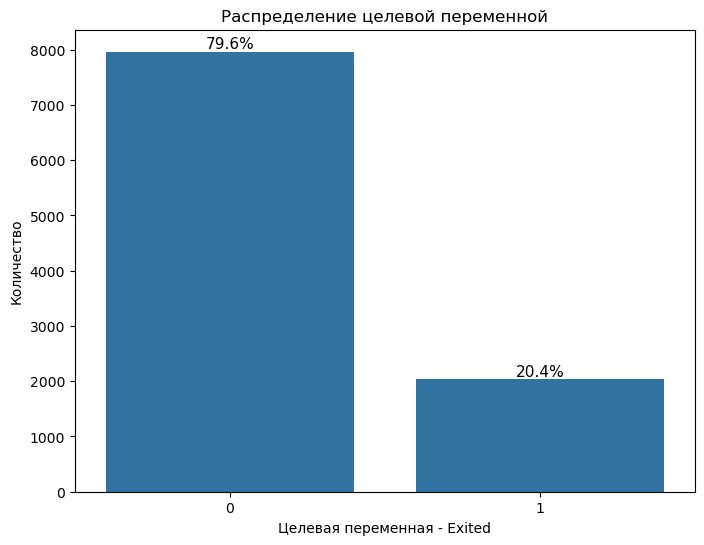

In [12]:
plt.figure(figsize=(8,6))

ax = sns.countplot(data=df, x='Exited')

total = len(df)

for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height / total:.1f}%'
    ax.annotate(
        percentage,
        (p.get_x() + p.get_width() / 2, height),
        ha='center', va='bottom',
        fontsize=11
    )

plt.xlabel('Целевая переменная - Exited')
plt.ylabel('Количество')
plt.title('Распределение целевой переменной')
plt.show()

In [13]:
df['Exited'].value_counts(normalize=True) * 100

Exited
0    79.62
1    20.38
Name: proportion, dtype: float64

На графике видно, что классы сильно несбалансированы — 79.6% клиентов остались, 20.4% ушли. Нужно учитывать это при выборе метрик (accuracy будет обманчива) и, возможно, при обучении моделей (class_weight / стратификация).

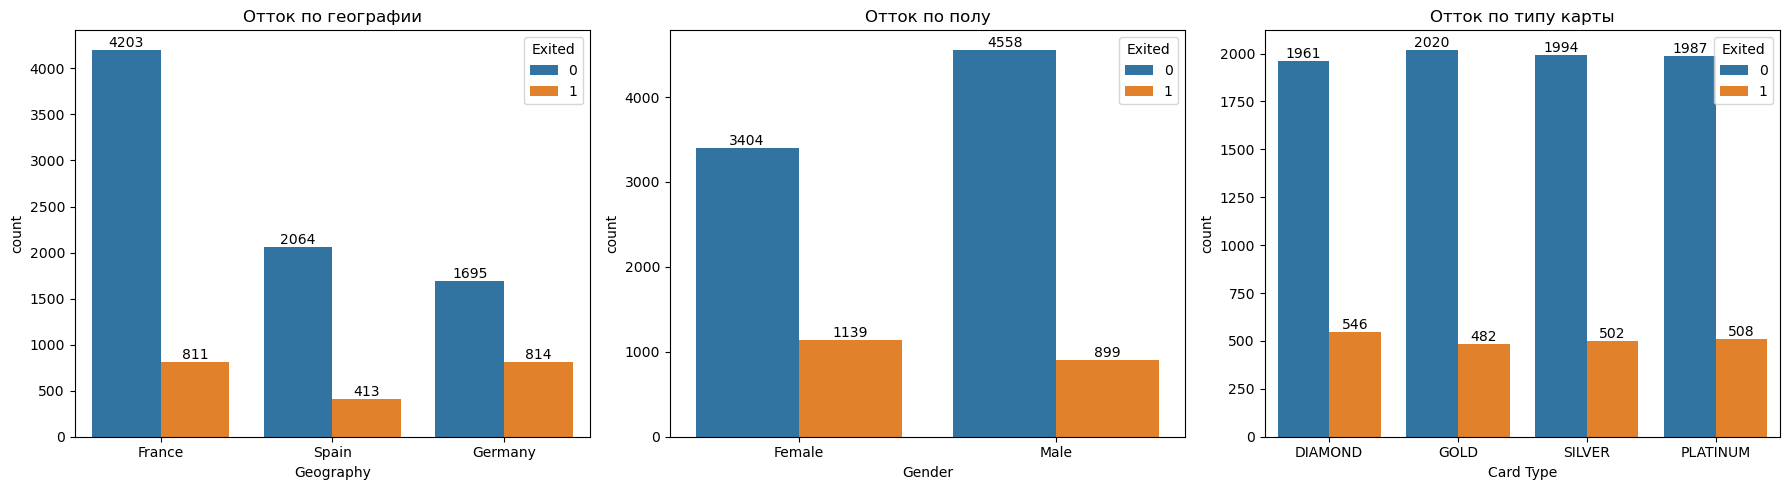

In [14]:
titles = {
    'Geography': 'Отток по географии',
    'Gender': 'Отток по полу',
    'Card Type': 'Отток по типу карты',
}

fig, axes = plt.subplots(1, len(categorical_columns), figsize=(18, 5))

for ax, column in zip(axes, categorical_columns):
    sns.countplot(data=df, x=column, hue='Exited', ax=ax)
    ax.set_title(titles[column])
    for container in ax.containers:
        ax.bar_label(container)

plt.tight_layout()
plt.show()


In [15]:
print(df.groupby('Geography')['Exited'].mean() * 100)
print(df.groupby('Gender')['Exited'].mean() * 100)
print(df.groupby('Card Type')['Exited'].mean() * 100)

Geography
France     16.174711
Germany    32.443204
Spain      16.673395
Name: Exited, dtype: float64
Gender
Female    25.071539
Male      16.474253
Name: Exited, dtype: float64
Card Type
DIAMOND     21.779019
GOLD        19.264588
PLATINUM    20.360721
SILVER      20.112179
Name: Exited, dtype: float64


На графике видно, что страна сильно влияет на отток — в Германии уходит ~32% клиентов против ~16% во Франции и Испании, хотя клиентов из Германии вдвое меньше. Пол тоже заметен: у женщин отток ~25%, у мужчин ~16%. А вот тип карты (Card Type) почти не влияет — отток держится в узком диапазоне 19–22% для всех типов, признак слабо полезен.

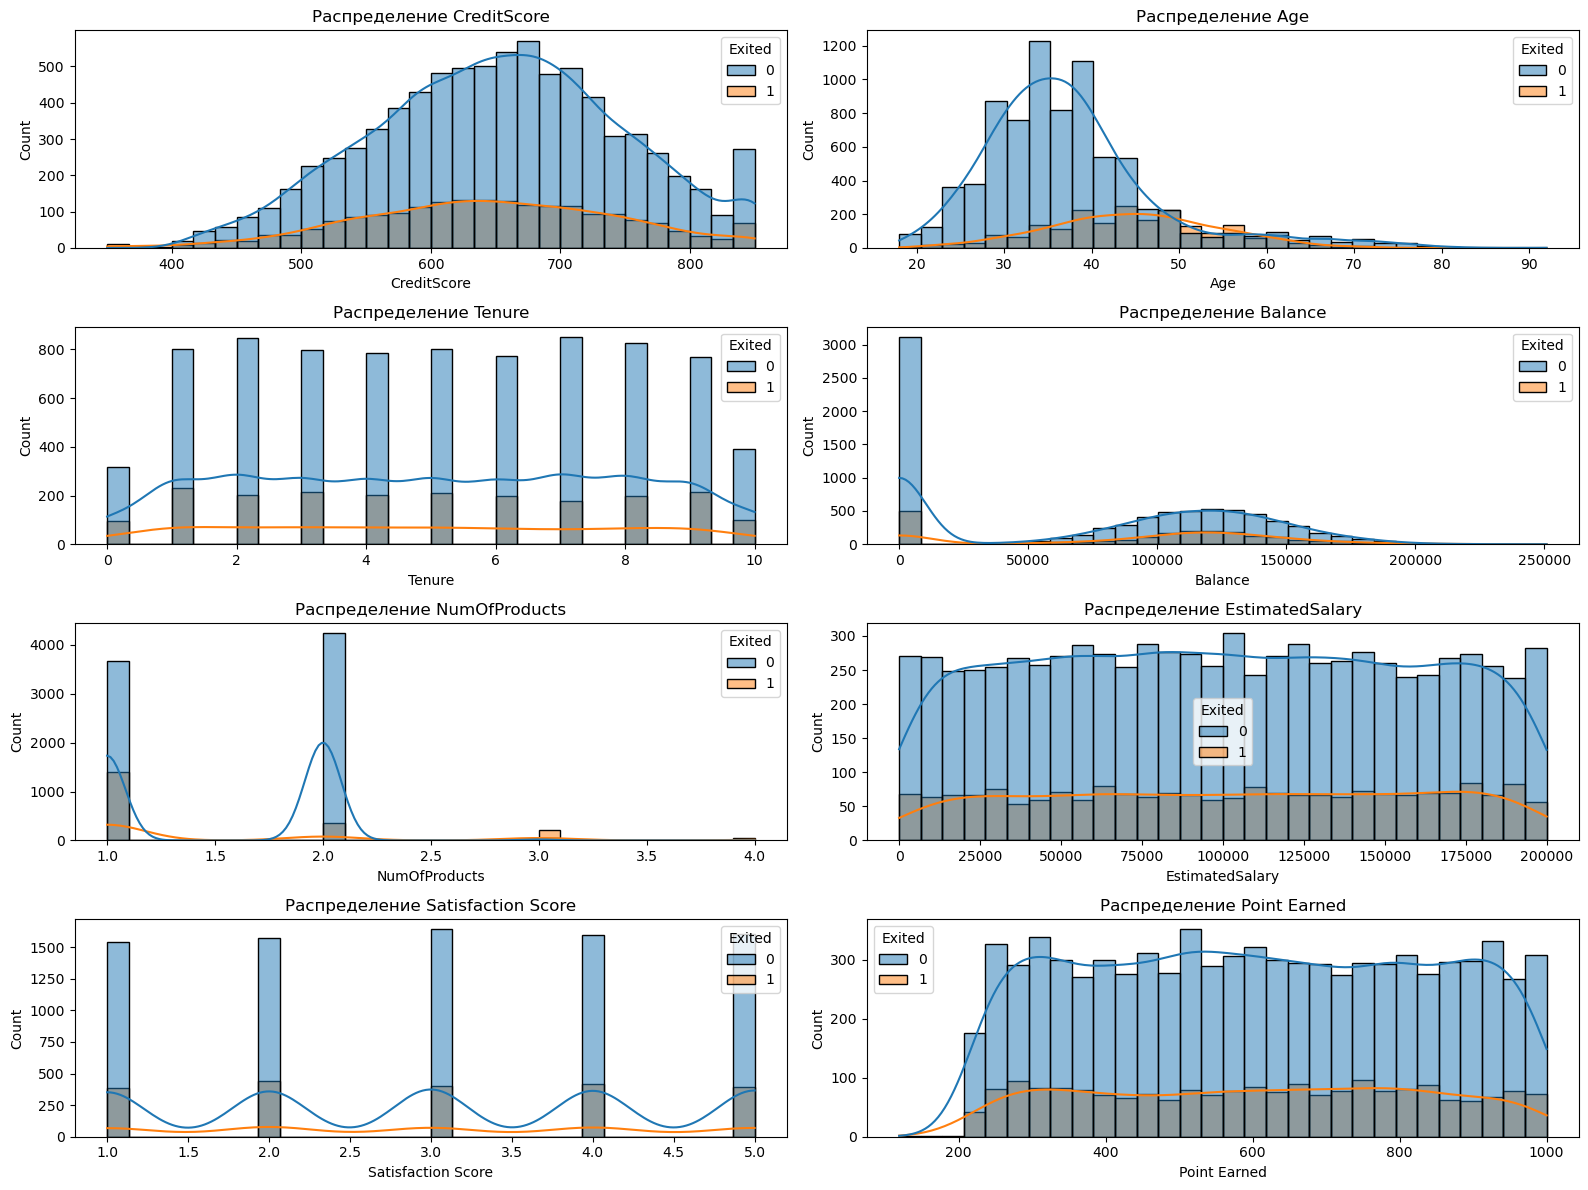

In [16]:
n_cols = 2
n_rows = -(-len(numeric_columns) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))
axes = axes.flatten()

for i, column in enumerate(numeric_columns):
    sns.histplot(data=df, x=column, hue='Exited', kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f'Распределение {column}')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [17]:
(df['Balance'] == 0).mean() * 100

36.17

На графиках видно, что Age — единственный численный признак с заметно разным распределением по классам (у ушедших смещение в старший возраст), остальные (CreditScore, EstimatedSalary, Tenure, Satisfaction Score, Point Earned) распределены практически одинаково для обоих классов — поодиночке слабые предикторы. Balance имеет выраженный пик в нуле (~36% клиентов с нулевым балансом).

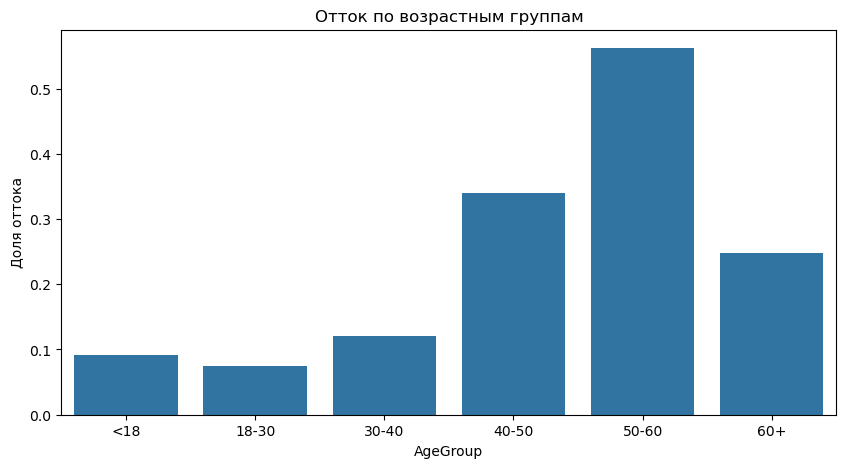

In [18]:
plt.figure(figsize=(10, 5))
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 18, 30, 40, 50, 60, 100],
    labels=['<18', '18-30', '30-40', '40-50', '50-60', '60+']
)
sns.barplot(data=df, x='AgeGroup', y='Exited', errorbar=None)
plt.ylabel('Доля оттока')
plt.title('Отток по возрастным группам')
plt.show()


In [19]:
df.groupby('AgeGroup', observed=True)['Exited'].mean() * 100

AgeGroup
<18       9.090909
18-30     7.502569
30-40    12.109638
40-50    33.965517
50-60    56.210790
60+      24.784483
Name: Exited, dtype: float64

На графике видно, что отток растёт с возрастом до пика в группе 50–60 лет (~56%), после 60 — падает обратно (~25%). Возраст — явно нелинейный признак, линейным моделям без преобразования (биннинг/полиномиальные фичи) будет сложно его использовать.

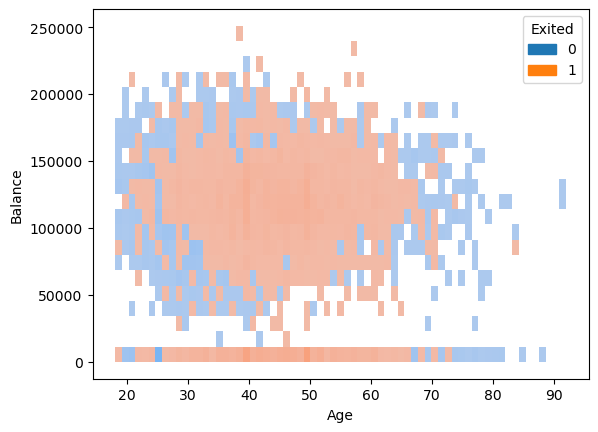

In [20]:
sns.histplot(data = df, x = 'Age', y = 'Balance', hue = 'Exited')
plt.show()

На графике видно, что ушедшие клиенты (Exited=1) концентрируются в старшей возрастной зоне независимо от баланса — баланс сам по себе не разделяет классы, определяющий фактор здесь именно возраст.

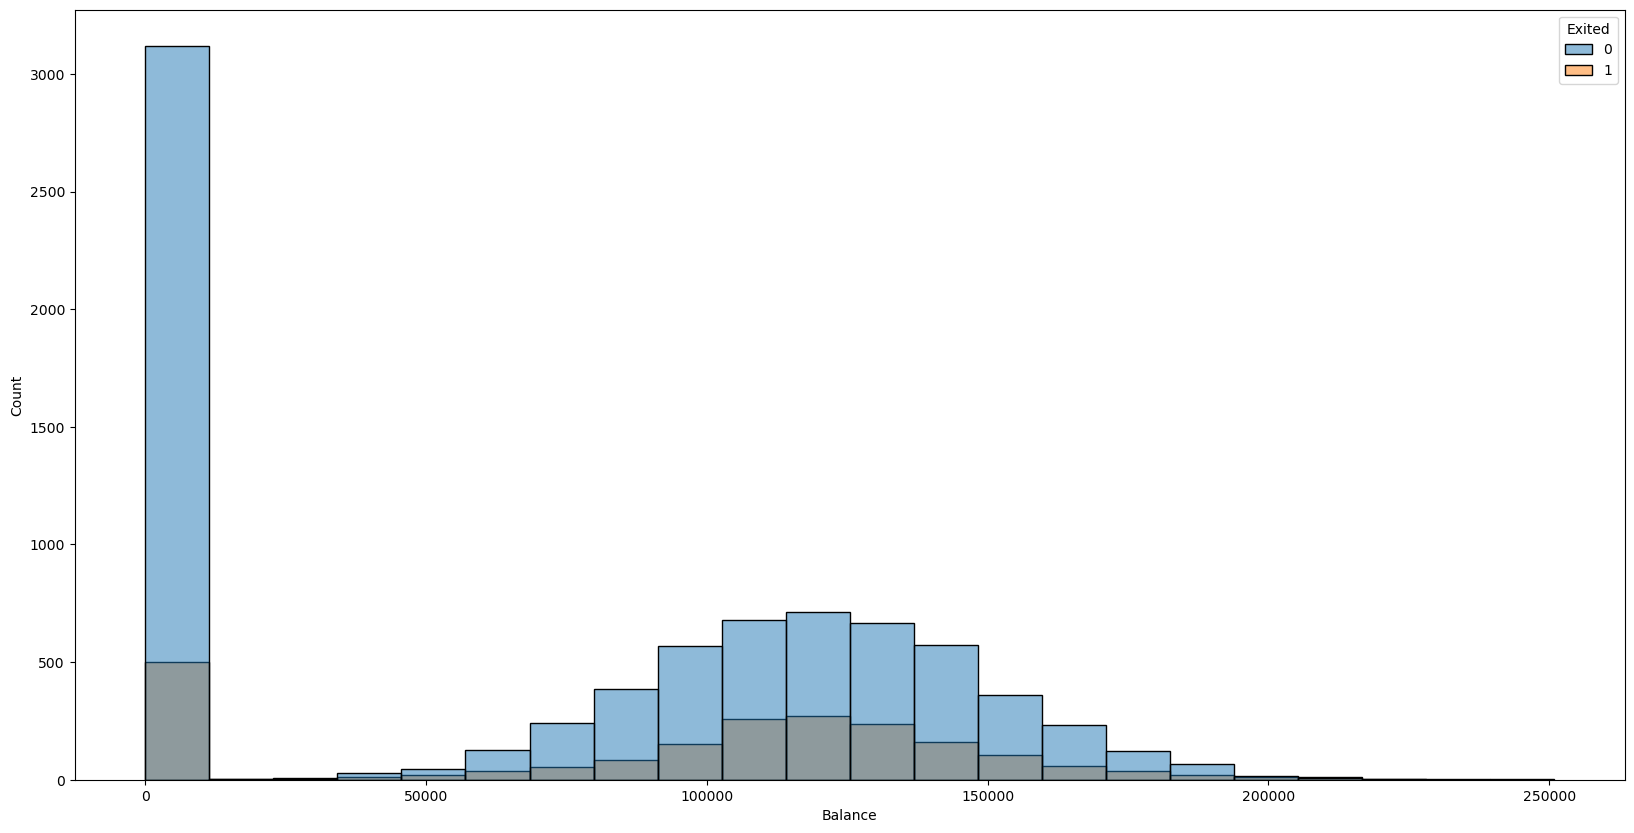

In [21]:
plt.figure(figsize=(20,10))
sns.histplot(data=df, 
             x='Balance',
             hue='Exited')
plt.show()

На графике видно, что распределение Balance бимодальное — большой пик в нуле и почти нормальный «купол» в районе 100–150k. Нулевой баланс — потенциально полезный бинарный признак (см. идею ниже), а не просто выброс.

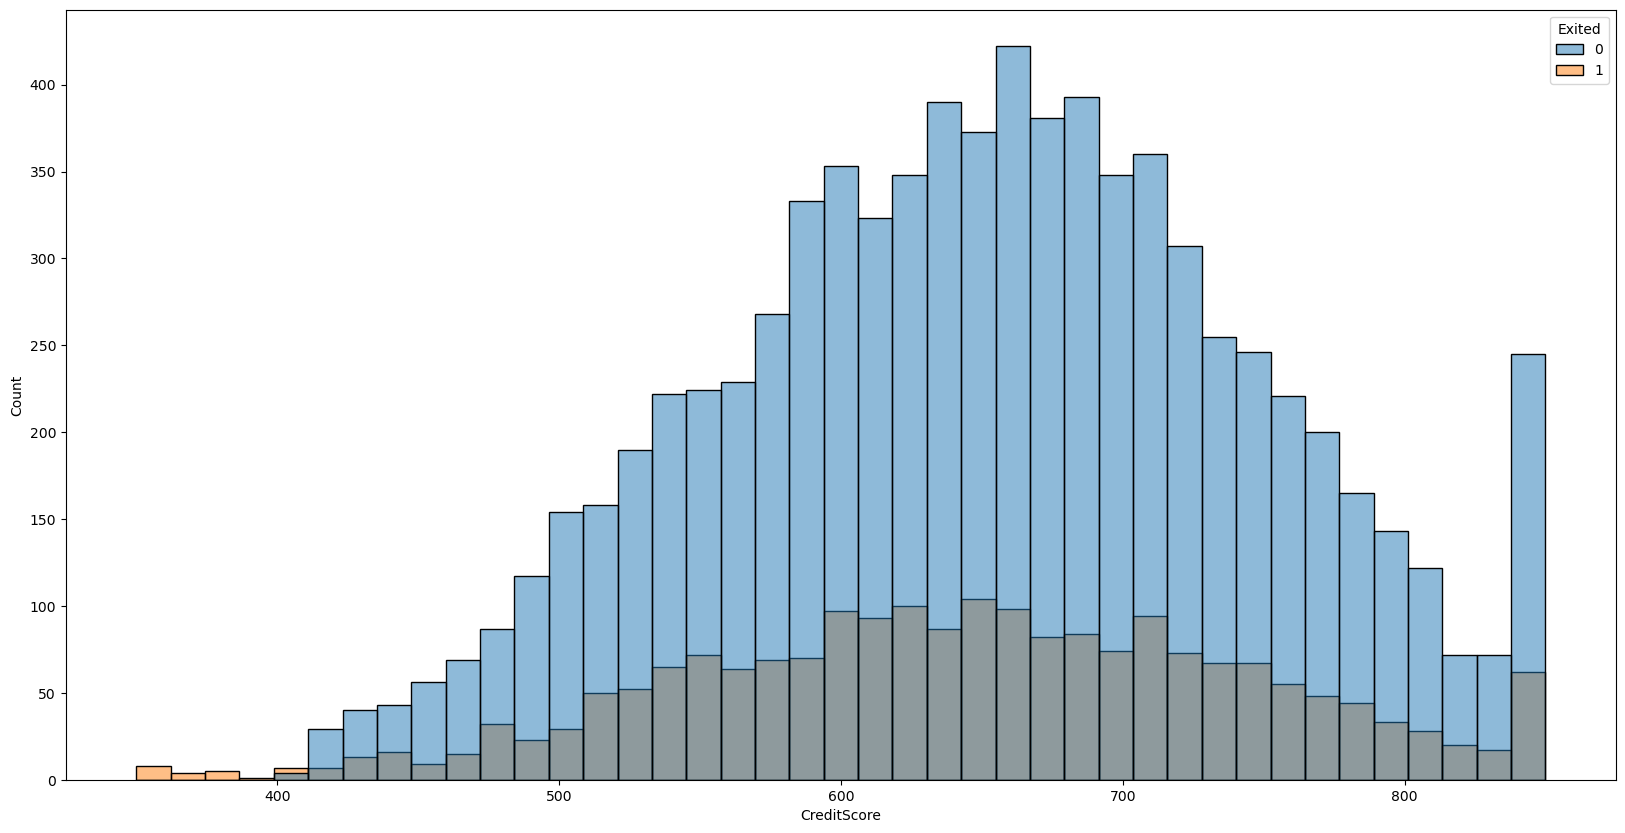

In [22]:
plt.figure(figsize=(20,10))
sns.histplot(data=df, 
             x='CreditScore',
             hue='Exited')
plt.show()

На графике видно, что CreditScore распределён близко к нормальному и почти одинаково для обеих групп — сам по себе слабый предиктор оттока, что согласуется с низкой корреляцией с Exited.

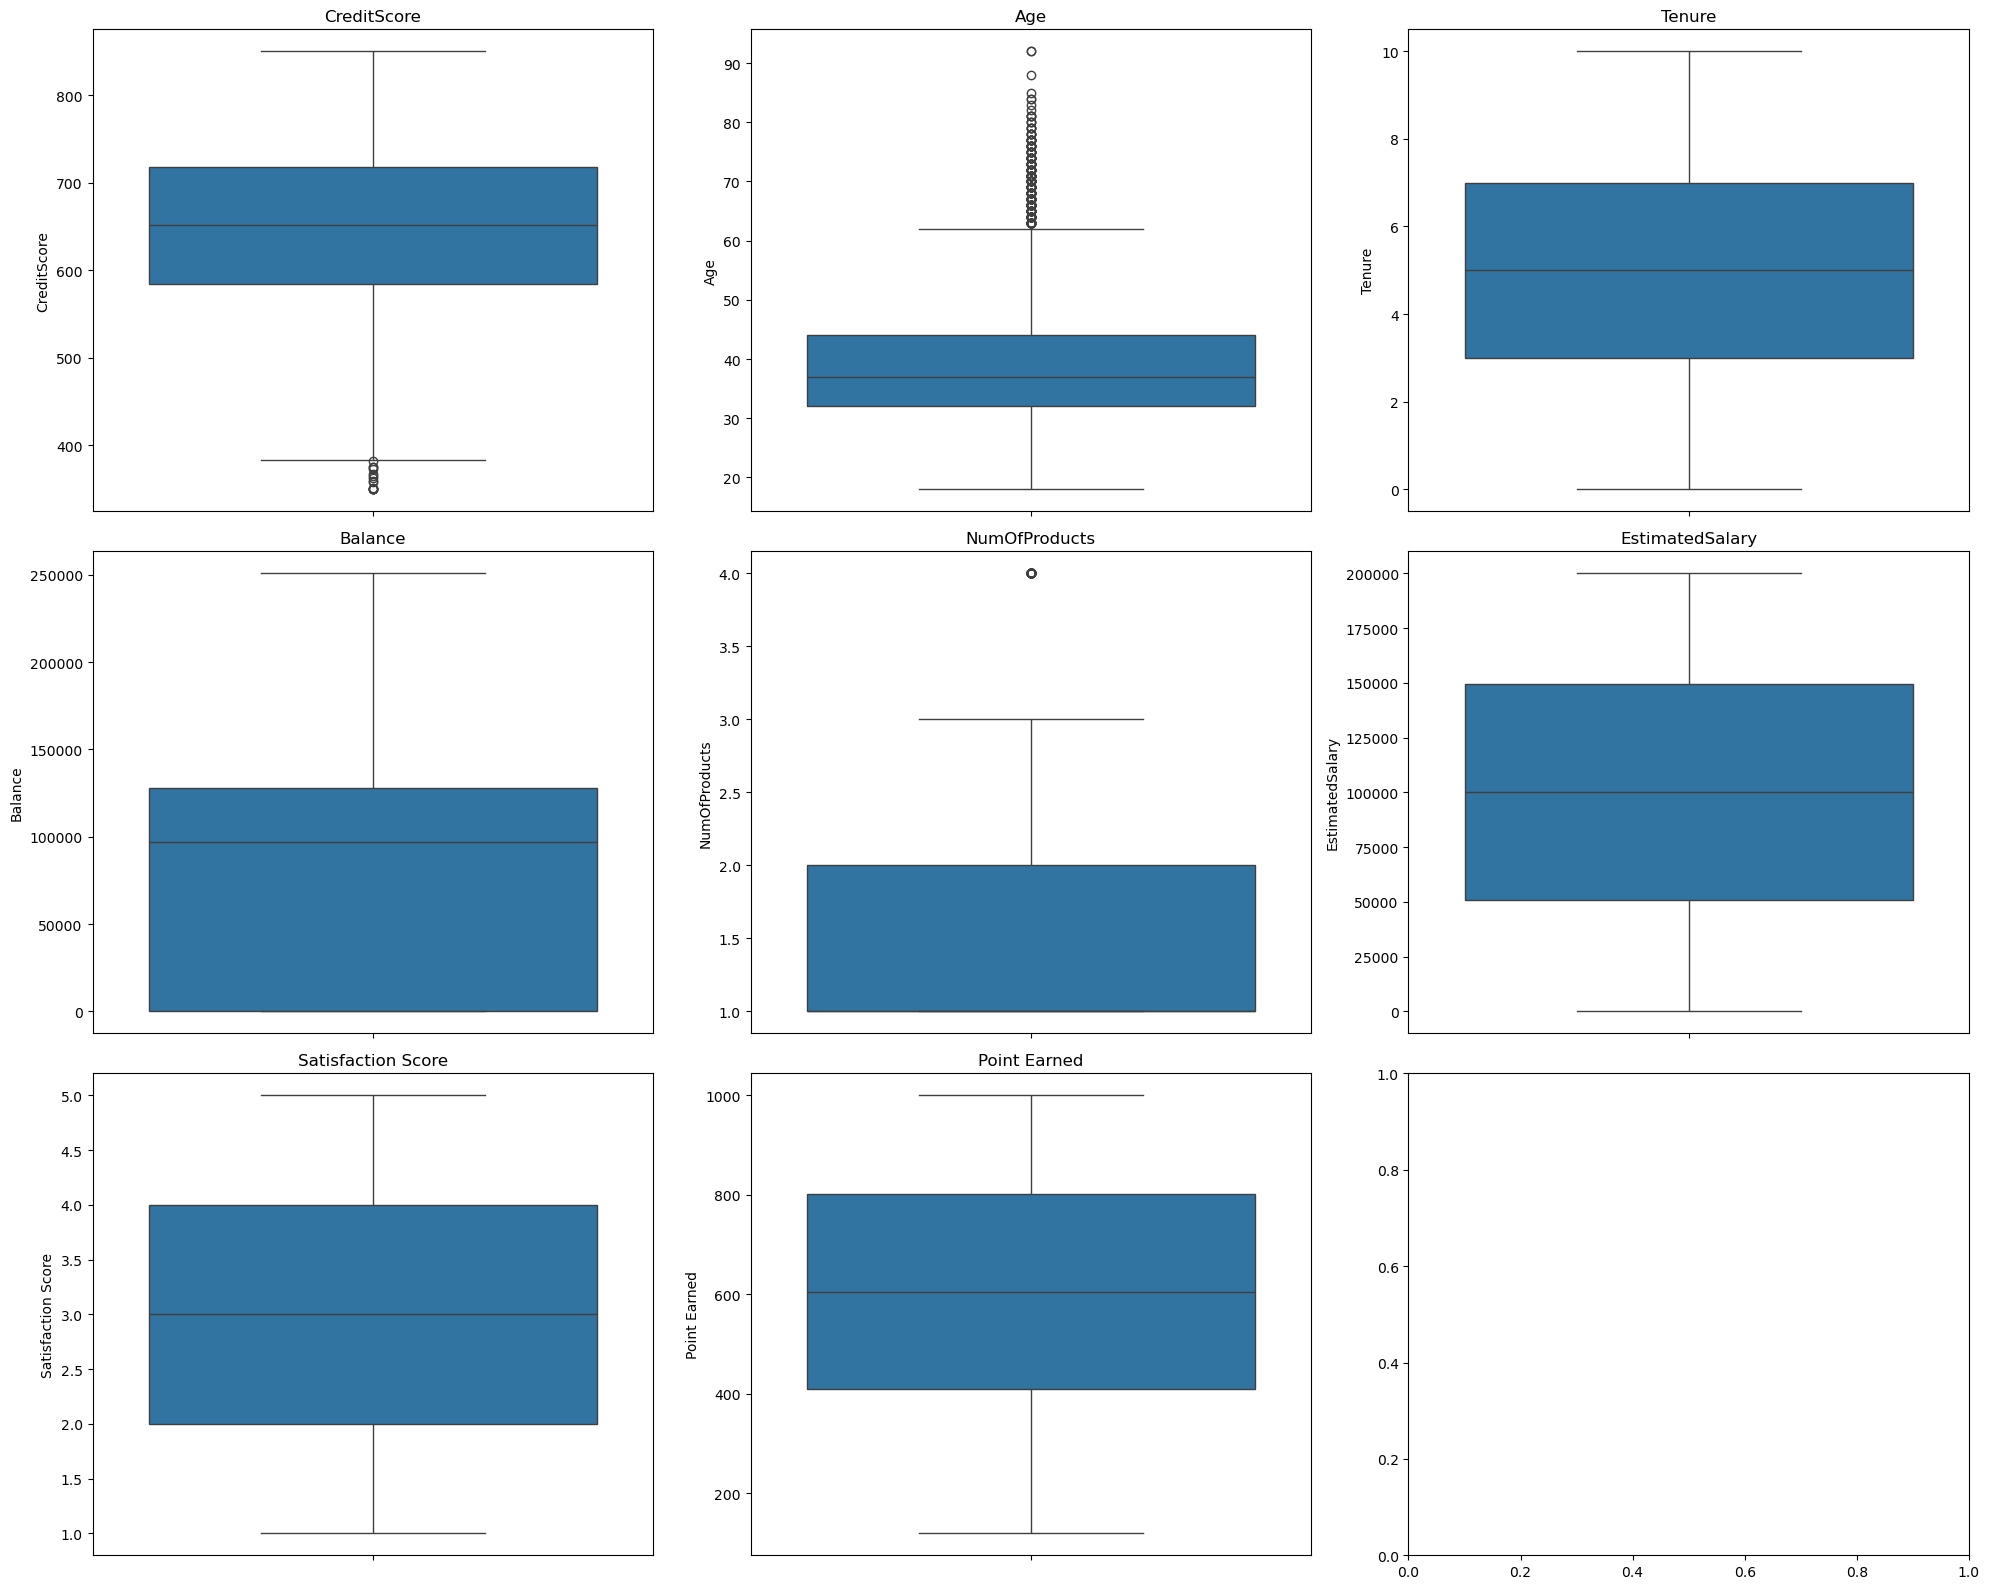

In [23]:
fig, axes = plt.subplots(3, 3, figsize=(20, 16))
axes = axes.flatten()
for i, col in enumerate(numeric_columns):
    sns.boxplot(data=df, y=col, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [24]:
df.groupby('NumOfProducts')['Exited'].mean() * 100

NumOfProducts
1     27.714398
2      7.603486
3     82.706767
4    100.000000
Name: Exited, dtype: float64

На графике видно, что заметные выбросы есть у CreditScore (низкий хвост) и Age (высокий хвост за счёт пожилых клиентов), у NumOfProducts выбросами выглядят значения 3–4 — при этом именно они дают экстремально высокий отток (83% и 100% соответственно), то есть это не шум, а сильный сигнал, который нельзя просто отбросить как выброс.

In [25]:
outlier_stats = []

for col in numeric_columns:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = df[(df[col] < low) | (df[col] > high)].shape[0]

    outlier_stats.append({
        'feature': col,
        'min': df[col].min(),
        'max': df[col].max(),
        'lower_bound': round(low, 1),
        'upper_bound': round(high, 1),
        'n_outliers': n_outliers,
        'outliers_%': round(n_outliers / len(df) * 100, 2),
    })

pd.DataFrame(outlier_stats)

,feature,min,max,lower_bound,upper_bound,n_outliers,outliers_%
0,CreditScore,350.00,850.00,383.0,919.0,15,0.15
1,Age,18.00,92.00,14.0,62.0,359,3.59
2,Tenure,0.00,10.00,-3.0,13.0,0,0.00
3,Balance,0.00,250898.09,-191466.4,319110.6,0,0.00
4,NumOfProducts,1.00,4.00,-0.5,3.5,60,0.60
5,EstimatedSalary,11.58,199992.48,-96577.1,296967.5,0,0.00
6,Satisfaction Score,1.00,5.00,-1.0,7.0,0,0.00
7,Point Earned,119.00,1000.00,-176.5,1387.5,0,0.00


На расчёте видно, что реальных выбросов почти нет: CreditScore — 0.15%, Age — 3.59%, NumOfProducts — 0.60%, у остальных признаков — 0%. При этом там, где IQR формально находит выбросы, это не аномалии, а естественные границы: CreditScore упирается в потолок шкалы (850, как в FICO), Age до 92 — просто пожилые клиенты, а NumOfProducts = 3/4 хоть и редки, но дают самый сильный сигнал в датасете (83% и 100% оттока) — обрезать их как выбросы значит выбросить самый ценный признак. Поэтому специально обрабатывать выбросы не будем: их мало, они реалистичны.

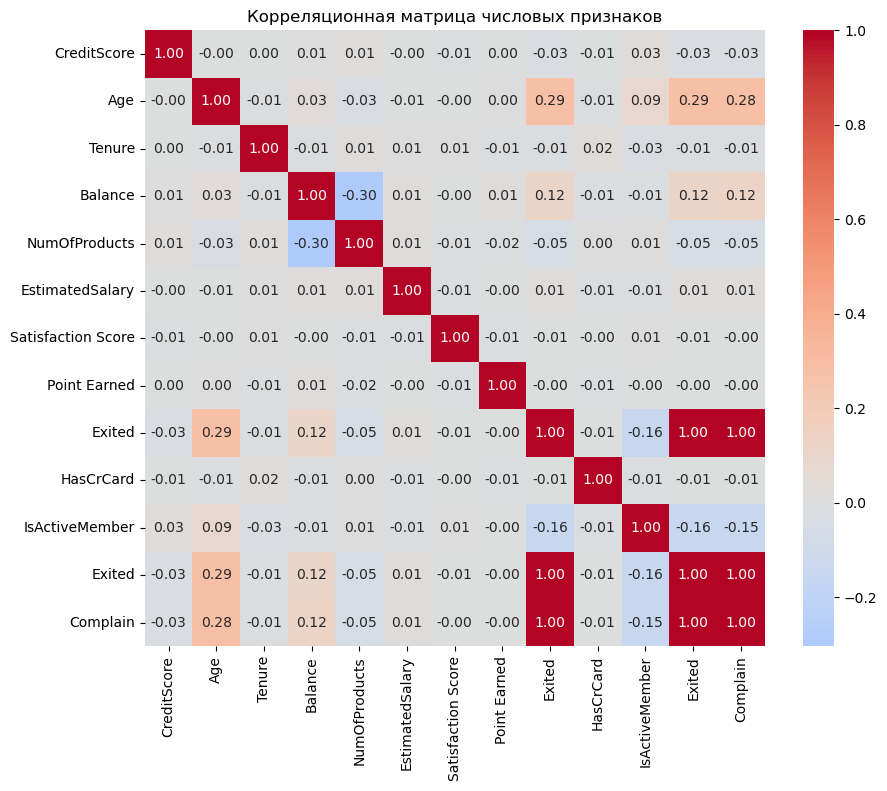

In [26]:
plt.figure(figsize=(10, 8))
corr = df[numeric_columns + ['Exited'] + binar_columns].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляционная матрица числовых признаков')
plt.show()

На графике видно, что среди «чистых» признаков сильнее всего с оттоком коррелируют Age (+0.29) и IsActiveMember (−0.16), у Balance слабая положительная связь (+0.12). Остальные численные признаки почти не коррелируют с Exited по отдельности — значит, отток, скорее всего, определяется комбинациями признаков, и деревья/бустинг должны работать лучше чистой линейной модели.

Отдельно бросается в глаза `Complain`: корреляция с `Exited` равна **0.996**, то есть признак почти дословно повторяет таргет (ниже посчитаем — расходятся всего 14 строк из 10000).

Это классическая утечка: жалоба фиксируется в момент ухода клиента, то есть на практике её ещё не будет в тот момент, когда мы хотим предсказать отток. Модель с `Complain` покажет почти идеальные метрики и на train, и на test, но в проде окажется бесполезной. Поэтому `Complain` из обучения исключаем.

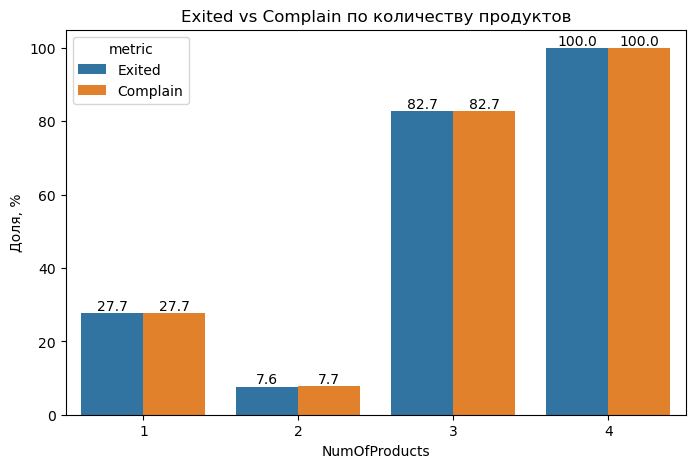

In [27]:
rates = df.groupby('NumOfProducts')[['Exited', 'Complain']].mean() * 100
rates_long = rates.reset_index().melt(id_vars='NumOfProducts', var_name='metric', value_name='rate')

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=rates_long, x='NumOfProducts', y='rate', hue='metric')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')
plt.ylabel('Доля, %')
plt.title('Exited vs Complain по количеству продуктов')
plt.show()

На графике видно, что доли `Exited` и `Complain` практически совпадают на каждом уровне `NumOfProducts`. Само по себе это **не** означает, что сигнал от `NumOfProducts` фиктивный: `Complain` совпадает с `Exited` в 99.86% строк (расходятся 14 записей из 10000), поэтому доли этих двух признаков будут совпадать в **любой** группировке по любому признаку — это тавтология, а не доказательство утечки именно здесь.

Правильный вывод: `Complain` — фактически копия таргета, её нужно исключить из обучения (что мы и делаем). А связь `NumOfProducts` → отток остаётся реальным и очень сильным сигналом, который модели должны использовать.

Оговорка по надёжности цифр при этом остаётся: группы с 3 и 4 продуктами очень маленькие (266 и 60 клиентов), поэтому доверительные интервалы вокруг 83% и 100% широкие. Переход 1 → 2 продукта (27.7% → 7.6% на выборках 5000+) статистически куда надёжнее.

In [28]:
(df['Balance'] == 0).sum()


3617

Нулевой баланс — не выброс, а отдельная группа клиентов. Сделаем из этого бинарный признак `ZeroBalance`.

## Вывод по EDA

- **Дисбаланс классов**: 79.6% / 20.4% — учитывать при выборе метрик и обучении.
- **Утечка данных**: `Complain` коррелирует с `Exited` на уровне 0.996 — исключить из обучения.
- **Сильные признаки** (видна выраженная разница по классам): `Age` (пик оттока в 50–60 лет), `Geography` (Германия ~32% против ~16% в остальных странах), `Gender` (женщины уходят чаще), `IsActiveMember`, `NumOfProducts` (3–4 продукта → почти гарантированный отток), нулевой `Balance`.
- **Слабые признаки поодиночке**: `CreditScore`, `EstimatedSalary`, `Tenure`, `Satisfaction Score`, `Point Earned`, `Card Type` — распределены почти одинаково для обоих классов, низкая корреляция с целевой переменной. Не выбрасываем — могут быть полезны в комбинации с другими признаками (для деревьев/бустинга/MLP).
- **Нелинейность**: связь Age и NumOfProducts с оттоком не монотонна/не линейна → линейным моделям нужны биннинг, полиномиальные признаки или взаимодействия; деревья и бустинг должны справляться с этим лучше «из коробки».

# 3. Feature Engineering

По итогам EDA берём в работу два признака, оба обоснованы графиками и расчётами выше:

1. **AgeGroup** — возраст сильно нелинейно связан с оттоком (7.5% → 12.1% → 34.0% → 56.2% → 24.8% по бинам), линейная модель такую зависимость не поймает без биннинга.
2. **ZeroBalance** — 36.2% клиентов имеют нулевой баланс, и это отдельная группа с другим оттоком (13.8% против 24.1% у клиентов с ненулевым балансом).

Дальше каждую модель обучаем дважды — на base-наборе и на наборе с этими двумя признаками, чтобы вклад FE был виден в числах.

In [29]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0,18, 30, 40, 50, 60, 100],
    labels=['<18','18-30', '30-40', '40-50', '50-60', '60+']
)

df['ZeroBalance'] = (df['Balance'] == 0).astype(int)

df[['Age', 'AgeGroup', 'Balance', 'ZeroBalance']].head()

,Age,AgeGroup,Balance,ZeroBalance
0,42,40-50,0.00,1
1,41,40-50,83807.86,0
2,42,40-50,159660.80,0
3,39,30-40,0.00,1
4,43,40-50,125510.82,0


In [30]:
print(df.groupby('AgeGroup', observed=True)['Exited'].mean() * 100)
print()
print(df.groupby('ZeroBalance')['Exited'].mean() * 100)

AgeGroup
<18       9.090909
18-30     7.502569
30-40    12.109638
40-50    33.965517
50-60    56.210790
60+      24.784483
Name: Exited, dtype: float64

ZeroBalance
0    24.095253
1    13.823611
Name: Exited, dtype: float64


Цифры совпадают с тем, что мы уже видели на графиках EDA — признаки созданы корректно, можно использовать в обучении наравне с базовыми.

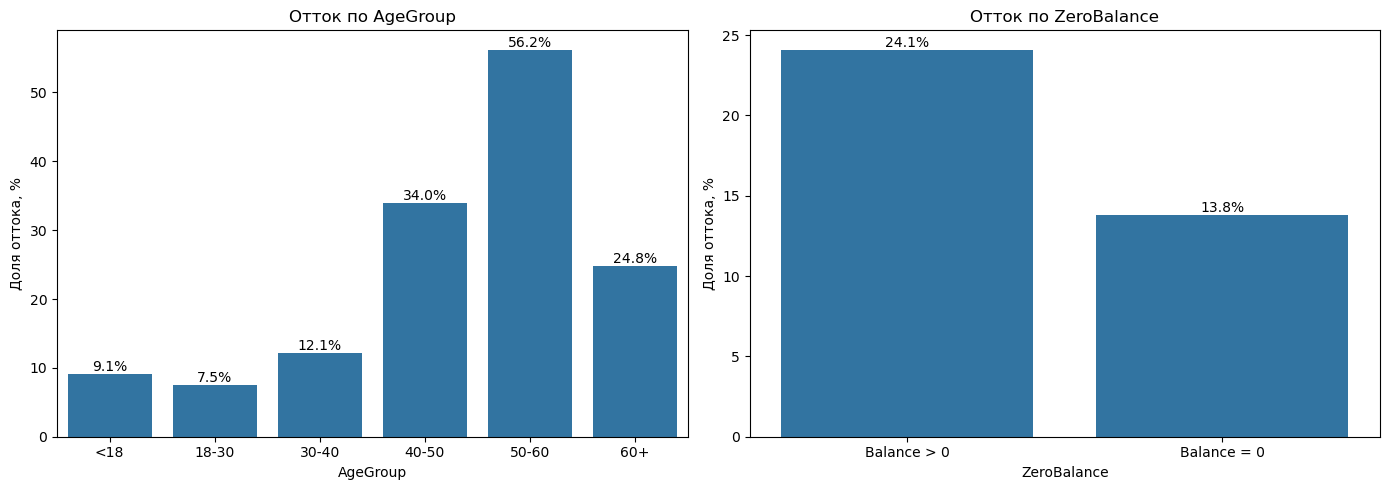

In [31]:
age_rate = (df.groupby('AgeGroup', observed=True)['Exited'].mean() * 100).reset_index()
zero_rate = (df.groupby('ZeroBalance')['Exited'].mean() * 100).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = sns.barplot(data=age_rate, x='AgeGroup', y='Exited', ax=axes[0])
ax1.bar_label(ax1.containers[0], fmt='%.1f%%')
axes[0].set_ylabel('Доля оттока, %')
axes[0].set_title('Отток по AgeGroup')

ax2 = sns.barplot(data=zero_rate, x='ZeroBalance', y='Exited', ax=axes[1])
ax2.bar_label(ax2.containers[0], fmt='%.1f%%')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Balance > 0', 'Balance = 0'])
axes[1].set_ylabel('Доля оттока, %')
axes[1].set_title('Отток по ZeroBalance')

plt.tight_layout()
plt.show()

На графике видно то же самое, что и в цифрах выше: отток по AgeGroup растёт нелинейно с пиком в 50-60 лет, а по ZeroBalance разница почти в два раза (13.8% против 24.1%) — оба признака визуально разделяют классы, в отличие от многих исходных числовых признаков.

## Вывод по Feature Engineering

Добавлено два признака:

* **AgeGroup** — разбиение возраста на интервалы, чтобы линейные модели увидели нелинейный профиль оттока;
* **ZeroBalance** — флаг нулевого баланса, отделяющий группу с заметно другим уровнем оттока.

# 4. Классические ML-модели


Все модели обучаются и сравниваются по одной схеме: 5-fold стратифицированная кросс-валидация на `X_train`, метрика — ROC-AUC (accuracy обманчива при дисбалансе 80/20).

**План раздела:**
* LogReg, Random Forest, LightGBM, KNN и SVM — каждая на base-наборе признаков и на наборе с FE, чтобы отдельно увидеть вклад feature engineering
* сводная таблица baseline-моделей
* подбор гиперпараметров через Optuna для трёх моделей: LogReg, Random Forest, LightGBM
* дальше, в разделе 5, — MLP и честное сравнение всех моделей на общем `X_test`

In [32]:
numeric_features_base = ['CreditScore','Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary','Satisfaction Score','Point Earned']

numeric_features_fe = ['CreditScore','Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary','Satisfaction Score', 'Point Earned','ZeroBalance']


category_features_base = ['Geography', 'Gender', 'Card Type']


category_features_fe = ['Geography', 'Gender', 'Card Type','AgeGroup']

In [33]:
X = df.drop(columns=['RowNumber', 'CustomerId', 'Surname', 'Complain', 'Exited'])
y = df['Exited']

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

## Logistic Regression

In [35]:
numeric_transformer_logreg_base = Pipeline([
    ('scaler',StandardScaler())
])


categorical_transformer_logreg_base = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_logreg_base = ColumnTransformer([
    (
        'numeric',
        numeric_transformer_logreg_base,
        numeric_features_base
    ),
    
    (
        'categorical',
        categorical_transformer_logreg_base,
        category_features_base
    )
])

In [36]:
logreg_base_model = Pipeline([
    (
        'preprocessor',
        preprocessor_logreg_base
    ),
    (
        'model',
        LogisticRegression(random_state=RANDOM_STATE)
    )
])

In [37]:
cv = StratifiedKFold(n_splits= 5, shuffle= True, random_state=RANDOM_STATE)

In [38]:
logreg_base_score = cross_val_score(
    estimator = logreg_base_model,
    X = X_train,
    y = y_train,
    cv = cv, 
    scoring= 'roc_auc'
)

In [39]:
print(f'ROC-AUC по фолдам: {np.round(logreg_base_score, 4)}')
print(f'ROC-AUC средний: {logreg_base_score.mean():.4f} ± {logreg_base_score.std():.4f}')

ROC-AUC по фолдам: [0.7529 0.7608 0.7716 0.7579 0.7706]
ROC-AUC средний: 0.7628 ± 0.0073


In [40]:
numeric_transformer_logreg_fe = Pipeline([
    ('scaler',StandardScaler())
])


categorical_transformer_logreg_fe = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_logreg_fe = ColumnTransformer([
    (
        'numeric',
        numeric_transformer_logreg_fe,
        numeric_features_fe
    ),
    
    (
        'categorical',
        categorical_transformer_logreg_fe,
        category_features_fe
    )
])

In [41]:
logreg_fe_model = Pipeline([
    (
        'preprocessor',
        preprocessor_logreg_fe
    ),
    (
        'model',
        LogisticRegression(random_state=RANDOM_STATE)
    )
])

In [42]:
logreg_fe_score = cross_val_score(
    estimator = logreg_fe_model,
    X = X_train,
    y = y_train,
    cv = cv, 
    scoring= 'roc_auc'
)

In [43]:
print(f'ROC-AUC по фолдам: {np.round(logreg_fe_score, 4)}')
print(f'ROC-AUC средний: {logreg_fe_score.mean():.4f} ± {logreg_fe_score.std():.4f}')

ROC-AUC по фолдам: [0.7684 0.7691 0.7895 0.784  0.7947]
ROC-AUC средний: 0.7812 ± 0.0107


### Результаты Logistic Regression

ROC-AUC: `0.7628` на base_df → `0.7812` на fe_df (+0.018). FE ощутимо помог линейной модели — ожидаемо, `AgeGroup`/`ZeroBalance` дают ей то, что она не может выучить сама (нелинейные пороги).

## Random Forest

In [44]:
categorical_transformer_tree = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])


preprocessor_tree_base = ColumnTransformer([
    (
        'numeric',
        'passthrough',
        numeric_features_base
    ),
    (
        'categorical',
        categorical_transformer_tree,
        category_features_base
    )
])

In [45]:
rf_model_base = Pipeline([
    (
        'preprocessor',
        preprocessor_tree_base
    ),
    
    (
        'model',
        RandomForestClassifier(random_state=RANDOM_STATE)
    )
    
])

In [46]:
rf_score_base = cross_val_score(
    estimator=rf_model_base, 
    X = X_train,
    y = y_train,
    cv = cv, 
    scoring='roc_auc'
)
print(f'ROC-AUC по фолдам: {np.round(rf_score_base, 4)}')
print(f'ROC-AUC средний: {rf_score_base.mean():.4f} ± {rf_score_base.std():.4f}')

ROC-AUC по фолдам: [0.8546 0.8412 0.8533 0.8441 0.8614]
ROC-AUC средний: 0.8509 ± 0.0073


In [47]:
preprocessor_tree_fe = ColumnTransformer([
    (
        'numeric',
        'passthrough',
        numeric_features_fe
    ),
    (
        'categorical',
        categorical_transformer_tree,
        category_features_fe
    )
])

In [48]:
rf_model_fe = Pipeline([
    (
        'preprocessor',
        preprocessor_tree_fe
    ),
    
    (
        'model',
        RandomForestClassifier(random_state=RANDOM_STATE)
    )
    
])

In [49]:
rf_score_fe = cross_val_score(
    estimator=rf_model_fe, 
    X = X_train,
    y = y_train,
    cv = cv, 
    scoring='roc_auc'
)
print(f'ROC-AUC по фолдам: {np.round(rf_score_fe, 4)}')
print(f'ROC-AUC средний: {rf_score_fe.mean():.4f} ± {rf_score_fe.std():.4f}')

ROC-AUC по фолдам: [0.8392 0.8263 0.8476 0.8414 0.8632]
ROC-AUC средний: 0.8435 ± 0.0121


### Результаты Random Forest

ROC-AUC: `0.8509` на base_df → `0.8435` на fe_df (−0.007). FE не помог и даже немного просел — похоже, дерево само находит эквивалент `AgeGroup`/`ZeroBalance` через сплиты по `Age`/`Balance`, а лишние one-hot колонки только добавляют шум/размерность.

## LightGBM

In [50]:
lgb_base_model= Pipeline([
    (
        'preprocessor',
        preprocessor_tree_base
    ),
    
    (
        'model',
        LGBMClassifier(n_estimators=300, learning_rate=0.1, max_depth=6, 
                           random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    )
])

In [51]:
lgb_base_score = cross_val_score(
    estimator=lgb_base_model,
    X = X_train,
    y = y_train,
    cv = cv,
    scoring='roc_auc'
)
print(f'ROC-AUC по фолдам: {np.round(lgb_base_score, 4)}')
print(f'ROC-AUC средний: {lgb_base_score.mean():.4f} ± {lgb_base_score.std():.4f}')


ROC-AUC по фолдам: [0.8248 0.8459 0.8484 0.8251 0.856 ]
ROC-AUC средний: 0.8400 ± 0.0128


In [52]:
lgb_fe_model= Pipeline([
    (
        'preprocessor',
        preprocessor_tree_fe
    ),
    
    (
        'model',
        LGBMClassifier(n_estimators=300, learning_rate=0.1, max_depth=6, 
                           random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    )
])

In [53]:
lgb_fe_score = cross_val_score(
    estimator=lgb_fe_model,
    X = X_train,
    y = y_train,
    cv =cv, 
    scoring = 'roc_auc'
)
print(f'ROC-AUC по фолдам: {np.round(lgb_fe_score, 4)}')
print(f'ROC-AUC средний: {lgb_fe_score.mean():.4f} ± {lgb_fe_score.std():.4f}')

ROC-AUC по фолдам: [0.8245 0.8447 0.8482 0.83   0.8538]
ROC-AUC средний: 0.8403 ± 0.0111


### Результаты LightGBM

Обе модели обучены с одинаковыми гиперпараметрами (`n_estimators=300, learning_rate=0.1, max_depth=6`), так что сравнение изолирует именно эффект FE.

ROC-AUC: `0.8400` на base_df → `0.8403` на fe_df (+0.0002, то есть в пределах шума). Картина та же, что у Random Forest: бустинг сам находит нужные пороги по `Age` и `Balance` через сплиты, поэтому явные `AgeGroup` / `ZeroBalance` ему ничего не добавляют. Дальше тюним LightGBM на base-наборе признаков.

## KNN

In [54]:
numeric_transformer_knn_base = Pipeline([
    ('scaler', StandardScaler())
])

categorical_transformer_knn_base = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_knn_base = ColumnTransformer([
    (
        'numeric',
        numeric_transformer_knn_base,
        numeric_features_base
    ),

    (
        'categorical',
        categorical_transformer_knn_base,
        category_features_base
    )
])

In [55]:
knn_base_model = Pipeline([
    (
        'preprocessor',
        preprocessor_knn_base
    ),
    (
        'model',
        KNeighborsClassifier()
    )
])

In [56]:
knn_base_score = cross_val_score(
    estimator = knn_base_model,
    X = X_train,
    y = y_train,
    cv = cv,
    scoring = 'roc_auc'
)

In [57]:
print(f'ROC-AUC по фолдам: {np.round(knn_base_score, 4)}')
print(f'ROC-AUC средний: {knn_base_score.mean():.4f} ± {knn_base_score.std():.4f}')

ROC-AUC по фолдам: [0.7498 0.7483 0.7687 0.7622 0.7821]
ROC-AUC средний: 0.7622 ± 0.0125


In [58]:
numeric_transformer_knn_fe = Pipeline([
    ('scaler', StandardScaler())
])

categorical_transformer_knn_fe = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_knn_fe = ColumnTransformer([
    (
        'numeric',
        numeric_transformer_knn_fe,
        numeric_features_fe
    ),

    (
        'categorical',
        categorical_transformer_knn_fe,
        category_features_fe
    )
])

In [59]:
knn_fe_model = Pipeline([
    (
        'preprocessor',
        preprocessor_knn_fe
    ),
    (
        'model',
        KNeighborsClassifier()
    )
])

In [60]:
knn_fe_score = cross_val_score(
    estimator = knn_fe_model,
    X = X_train,
    y = y_train,
    cv = cv,
    scoring = 'roc_auc'
)

In [61]:
print(f'ROC-AUC по фолдам: {np.round(knn_fe_score, 4)}')
print(f'ROC-AUC средний: {knn_fe_score.mean():.4f} ± {knn_fe_score.std():.4f}')

ROC-AUC по фолдам: [0.7598 0.7467 0.7607 0.7824 0.7997]
ROC-AUC средний: 0.7699 ± 0.0188


### Результаты KNN

ROC-AUC: `0.7622` на base_df → `0.7699` на fe_df (+0.008). Небольшой, но положительный эффект — KNN тоже выигрывает от явного биннинга возраста, хоть и слабее, чем LogReg.

## SVM

In [62]:
numeric_transformer_svm_base = Pipeline([
    ('scaler', StandardScaler())
])

categorical_transformer_svm_base = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_svm_base = ColumnTransformer([
    (
        'numeric',
        numeric_transformer_svm_base,
        numeric_features_base
    ),

    (
        'categorical',
        categorical_transformer_svm_base,
        category_features_base
    )
])

In [63]:
svm_base_model = Pipeline([
    (
        'preprocessor',
        preprocessor_svm_base
    ),
    (
        'model',
        SVC(kernel='rbf', probability=False, random_state=RANDOM_STATE)
    )
])

In [64]:
svm_base_score = cross_val_score(
    estimator = svm_base_model,
    X = X_train,
    y = y_train,
    cv = cv,
    scoring = 'roc_auc'
)

In [65]:
print(f'ROC-AUC по фолдам: {np.round(svm_base_score, 4)}')
print(f'ROC-AUC средний: {svm_base_score.mean():.4f} ± {svm_base_score.std():.4f}')

ROC-AUC по фолдам: [0.8258 0.809  0.8267 0.8161 0.8397]
ROC-AUC средний: 0.8234 ± 0.0104


In [66]:
numeric_transformer_svm_fe = Pipeline([
    ('scaler', StandardScaler())
])

categorical_transformer_svm_fe = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_svm_fe = ColumnTransformer([
    (
        'numeric',
        numeric_transformer_svm_fe,
        numeric_features_fe
    ),

    (
        'categorical',
        categorical_transformer_svm_fe,
        category_features_fe
    )
])

In [67]:
svm_fe_model = Pipeline([
    (
        'preprocessor',
        preprocessor_svm_fe
    ),
    (
        'model',
        SVC(kernel='rbf', probability=False, random_state=RANDOM_STATE)
    )
])

In [68]:
svm_fe_score = cross_val_score(
    estimator = svm_fe_model,
    X = X_train,
    y = y_train,
    cv = cv,
    scoring = 'roc_auc'
)

In [69]:
print(f'ROC-AUC по фолдам: {np.round(svm_fe_score, 4)}')
print(f'ROC-AUC средний: {svm_fe_score.mean():.4f} ± {svm_fe_score.std():.4f}')

ROC-AUC по фолдам: [0.8301 0.8097 0.829  0.8138 0.8309]
ROC-AUC средний: 0.8227 ± 0.0091


### Результаты SVM

ROC-AUC: `0.8234` на base_df → `0.8227` на fe_df (−0.001, в пределах шума). RBF-ядро само по себе умеет строить нелинейные границы, поэтому явный FE почти ничего не добавляет — похожая картина на деревья, хоть и не так выражено.

## Сравнение baseline-моделей

In [70]:
model_scores = {
    'LogReg (base)': logreg_base_score,
    'LogReg (FE)': logreg_fe_score,
    'Random Forest (base)': rf_score_base,
    'Random Forest (FE)': rf_score_fe,
    'LightGBM (base)': lgb_base_score,
    'LightGBM (FE)': lgb_fe_score,
    'KNN (base)': knn_base_score,
    'KNN (FE)': knn_fe_score,
    'SVM (base)': svm_base_score,
    'SVM (FE)': svm_fe_score,
}

comparison = pd.DataFrame({
    'ROC-AUC mean': {name: scores.mean() for name, scores in model_scores.items()},
    'ROC-AUC std': {name: scores.std() for name, scores in model_scores.items()},
}).sort_values('ROC-AUC mean', ascending=False)

comparison

,ROC-AUC mean,ROC-AUC std
Random Forest (base),0.850926,0.007348
Random Forest (FE),0.843529,0.012055
LightGBM (FE),0.840259,0.011147
LightGBM (base),0.840040,0.012773
SVM (base),0.823439,0.010399
SVM (FE),0.822707,0.009055
LogReg (FE),0.781151,0.010685
KNN (FE),0.769853,0.018794
LogReg (base),0.762763,0.007282
KNN (base),0.762226,0.012499


На текущем этапе (без тюнинга гиперпараметров) лучшие результаты у Random Forest и LightGBM на base_df — деревянные модели сильнее классики/KNN/SVM и без ручного FE, что согласуется с выводом EDA о нелинейности признаков. FE явно помогает только LogReg и немного KNN — моделям, которые не умеют сами находить нелинейные пороги. Для деревьев и SVM с RBF-ядром FE эффекта не даёт или слегка мешает. 

## Подбор гиперпараметров: LogReg, Random Forest и LightGBM

Каждая модель тюнится через Optuna по той же 5-fold кросс-валидации и той же метрике ROC-AUC, что и baseline, — поэтому результаты напрямую сравнимы с таблицей выше.

### LogReg tuned 

In [71]:
def logreg_tun(trial):
    C = trial.suggest_float('C',1e-3, 100, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1','l2'])
    solver = trial.suggest_categorical('solver', ['liblinear','saga'])
    class_weight  = trial.suggest_categorical('class_weight', ['balanced',None])
    model = Pipeline([
        (
            'preprocessor',
            preprocessor_logreg_fe
        ),
        (
            'model',
            LogisticRegression(C=C, penalty=penalty,class_weight=class_weight,solver=solver, random_state=RANDOM_STATE, max_iter=5000)
        )
    ])
    return cross_val_score(model,X_train,y_train, cv = cv, scoring= 'roc_auc').mean()

study_logreg = optuna.create_study(direction='maximize',sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_logreg.optimize(logreg_tun, n_trials=100)

In [72]:
print(f'Trials: {len(study_logreg.trials)}')
print(f'Лучший ROC-AUC: {study_logreg.best_value:.4f}')
print(f'Лучшие параметры: {study_logreg.best_params}')

Trials: 100
Лучший ROC-AUC: 0.7818
Лучшие параметры: {'C': 0.09777245048925434, 'penalty': 'l1', 'solver': 'saga', 'class_weight': 'balanced'}


### Logreg с лучими параметрами

In [73]:
logreg_tuned_model = Pipeline([
    ('preprocessor', preprocessor_logreg_fe),
    ('model', LogisticRegression(**study_logreg.best_params, max_iter=5000, random_state=RANDOM_STATE))
])

logreg_tuned_score = cross_val_score(logreg_tuned_model, X_train, y_train, cv=cv, scoring='roc_auc')
print(f'ROC-AUC по фолдам: {np.round(logreg_tuned_score, 4)}')
print(f'ROC-AUC по всей модели: {logreg_tuned_score.mean():.4f}')
print(f'Diff к LogReg (FE): {logreg_tuned_score.mean() - logreg_fe_score.mean():+.4f}')

ROC-AUC по фолдам: [0.7691 0.7685 0.7918 0.7846 0.7951]
ROC-AUC по всей модели: 0.7818
Diff к LogReg (FE): +0.0007


### RandomForest tuned

In [74]:
def rf_tune(trial):
    n_estimators = trial.suggest_int('n_estimators', 10,500)
    criterion = trial.suggest_categorical('criterion', ["gini", "entropy", "log_loss"])
    min_samples_split = trial.suggest_int('min_samples_split', 2,8)
    class_weight  = trial.suggest_categorical('class_weight', ['balanced',None])
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    model = Pipeline([
        (
            'preprocessor',
            preprocessor_tree_base
        ),
        
        (
            'model',
            RandomForestClassifier(
                n_estimators= n_estimators,
                criterion=criterion,
                min_samples_split=min_samples_split,
                class_weight=class_weight,
                min_samples_leaf=min_samples_leaf,
                max_features=max_features,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ])
    return cross_val_score(estimator=model, X = X_train, y = y_train, cv = cv, scoring='roc_auc').mean()

study_rf = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed= RANDOM_STATE))
study_rf.optimize(rf_tune,n_trials=300)

In [75]:
print(f'Trials: {len(study_rf.trials)}')
print(f'Лучший ROC-AUC: {study_rf.best_value:.4f}')
print(f'Лучшие параметры: {study_rf.best_params}')

Trials: 300
Лучший ROC-AUC: 0.8585
Лучшие параметры: {'n_estimators': 320, 'criterion': 'log_loss', 'min_samples_split': 2, 'class_weight': None, 'min_samples_leaf': 4, 'max_features': 'log2'}


In [76]:
rf_tuned_model = Pipeline([
    (
        'preprocessor',
        preprocessor_tree_base
    ),
    (
        'model',
        RandomForestClassifier(**study_rf.best_params, random_state=RANDOM_STATE, n_jobs=-1)
    )
])

rf_tuned_score = cross_val_score(rf_tuned_model, X_train, y_train, cv=cv, scoring='roc_auc')

In [77]:
print(f'ROC-AUC по фолдам: {np.round(rf_tuned_score, 4)}')
print(f'ROC-AUC по всей модели: {rf_tuned_score.mean():.4f}')
print(f'Diff к RF (base): {rf_tuned_score.mean() - rf_score_base.mean():+.4f}')

ROC-AUC по фолдам: [0.8586 0.8496 0.8641 0.8536 0.8668]
ROC-AUC по всей модели: 0.8585
Diff к RF (base): +0.0076


In [78]:
def lgb_tune(trial):
    n_estimators = trial.suggest_int('n_estimators', 100, 1000)
    learning_rate = trial.suggest_float('learning_rate', 1e-3, 0.3, log=True)
    num_leaves = trial.suggest_int('num_leaves', 15, 255)
    max_depth = trial.suggest_int('max_depth', 3, 15)
    min_child_samples = trial.suggest_int('min_child_samples', 5, 100)
    subsample = trial.suggest_float('subsample', 0.5, 1.0)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0)
    reg_alpha = trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True)
    reg_lambda = trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True)
    class_weight = trial.suggest_categorical('class_weight', ['balanced', None])

    model = Pipeline([
        (
            'preprocessor',
            preprocessor_tree_base
        ),
        (
            'model',
            LGBMClassifier(
                n_estimators=n_estimators,
                learning_rate=learning_rate,
                num_leaves=num_leaves,
                max_depth=max_depth,
                min_child_samples=min_child_samples,
                subsample=subsample,
                subsample_freq=1,
                colsample_bytree=colsample_bytree,
                reg_alpha=reg_alpha,
                reg_lambda=reg_lambda,
                class_weight=class_weight,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbose=-1
            )
        )
    ])

    return cross_val_score(estimator=model, X=X_train, y=y_train, cv=cv, scoring='roc_auc').mean()

study_lgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgb.optimize(lgb_tune, n_trials=150)

In [79]:
print(f'Trials: {len(study_lgb.trials)}')
print(f'Лучший ROC-AUC: {study_lgb.best_value:.4f}')
print(f'Лучшие параметры: {study_lgb.best_params}')

Trials: 150
Лучший ROC-AUC: 0.8655
Лучшие параметры: {'n_estimators': 455, 'learning_rate': 0.00836576075968292, 'num_leaves': 15, 'max_depth': 13, 'min_child_samples': 7, 'subsample': 0.6202816446242189, 'colsample_bytree': 0.749539459263221, 'reg_alpha': 0.0020085950263605138, 'reg_lambda': 4.2650040146254595e-06, 'class_weight': None}


In [80]:
lgb_tuned_model = Pipeline([
    (
        'preprocessor',
        preprocessor_tree_base
    ),
    (
        'model',
        LGBMClassifier(**study_lgb.best_params, subsample_freq=1,
                       random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    )
])

lgb_tuned_score = cross_val_score(
    estimator=lgb_tuned_model,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring='roc_auc'
)

In [81]:
print(f'ROC-AUC по фолдам: {np.round(lgb_tuned_score, 4)}')
print(f'ROC-AUC по всей модели: {lgb_tuned_score.mean():.4f}')
print(f'Diff к LightGBM (base): {lgb_tuned_score.mean() - lgb_base_score.mean():+.4f}')
print(f'Сходится с study_lgb.best_value: {study_lgb.best_value:.4f}')

ROC-AUC по фолдам: [0.8624 0.8639 0.874  0.8575 0.8698]
ROC-AUC по всей модели: 0.8655
Diff к LightGBM (base): +0.0255
Сходится с study_lgb.best_value: 0.8655


# 5. Нейронная сеть MLP (PyTorch)

Строим MLP на тех же признаках, что использовала логистическая регрессия (`numeric_features_fe` + `category_features_fe` со `StandardScaler` / `OneHotEncoder`): MLP — тоже градиентная модель, ей нужны нормализованные входы и явные нелинейные пороги (`AgeGroup`, `ZeroBalance`), которые она из сырых `Age` / `Balance` выучивает хуже деревьев.

**Как выбираем архитектуру.** Не угадываем числа, а ставим три эксперимента и смотрим на графики обучения:
1. **Глубина и ширина** — сколько слоёв и нейронов реально нужно.
2. **Регуляризация** — Dropout, BatchNorm, weight decay по отдельности и вместе.
3. **Оптимизатор и learning rate** — Adam / AdamW / SGD и снижение lr по расписанию.

Каждый следующий эксперимент стартует от победителя предыдущего, победитель выбирается по коду, а не вручную.

**Дисбаланс классов** (79.6% / 20.4%) учитываем весами классов в `CrossEntropyLoss` — это не трогает данные и не меняет размер эпохи.

**Метрики.** Основная — ROC-AUC (как и у классических моделей выше), дополнительно accuracy. По эпохам логируем метрики и на train, и на val: без train-кривой не видно, переобучается сеть или нет.

In [82]:
import time
from functools import partial

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


def set_seed(seed=RANDOM_STATE):
    """Фиксируем случайность, иначе результаты сети не воспроизводятся между запусками."""
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed()

Device: cpu


## Подготовка данных

Из `X_train` выделяем валидацию — на ней сравниваем конфигурации и выбираем число эпох. `X_test` не участвует ни в обучении, ни в выборе гиперпараметров: препроцессор фитим только на train-части.


In [83]:
preprocessor_mlp = ColumnTransformer([
    ('numeric', StandardScaler(), numeric_features_fe),
    ('categorical', OneHotEncoder(handle_unknown='ignore'), category_features_fe)
])

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train
)

X_tr_proc = preprocessor_mlp.fit_transform(X_tr)
X_val_proc = preprocessor_mlp.transform(X_val)

def to_dense(a):
    """OneHotEncoder может вернуть sparse-матрицу, а PyTorch нужен обычный массив."""
    return a.toarray() if hasattr(a, 'toarray') else a

def make_loader(X, y, batch_size=64, shuffle=True):
    X_t = torch.tensor(to_dense(X), dtype=torch.float32)
    y_t = torch.tensor(np.asarray(y), dtype=torch.long)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_tr_proc, y_tr, batch_size=64, shuffle=True)
train_eval_loader = make_loader(X_tr_proc, y_tr, batch_size=512, shuffle=False)
val_loader = make_loader(X_val_proc, y_val, batch_size=512, shuffle=False)

INPUT_DIM = X_tr_proc.shape[1]
print(f'Признаков на входе: {INPUT_DIM}')
print(f'train: {len(y_tr)}, val: {len(y_val)}, test: {len(y_test)}')


Признаков на входе: 26
train: 6400, val: 1600, test: 2000


In [84]:
counts = np.bincount(y_tr)
class_weights = torch.tensor(len(y_tr) / (2 * counts), dtype=torch.float32).to(device)
print(f'Объектов в классах: {counts}, веса: {class_weights.cpu().numpy().round(3)}')

Объектов в классах: [5096 1304], веса: [0.628 2.454]


## Архитектура

Собираем сеть обычным `nn.Sequential`: блок `Linear → [BatchNorm] → ReLU → [Dropout]`, повторённый по числу слоёв, и линейный выход на 2 класса (под `CrossEntropyLoss`).

Активация — ReLU: стандартный выбор для полносвязных сетей, не насыщается и не даёт затухающих градиентов, в отличие от sigmoid/tanh.

In [85]:
def make_mlp(hidden_dims=(64, 32), dropout=0.0, batchnorm=False):
    layers = []
    prev_dim = INPUT_DIM
    for h in hidden_dims:
        layers.append(nn.Linear(prev_dim, h))
        if batchnorm:
            layers.append(nn.BatchNorm1d(h))
        layers.append(nn.ReLU())
        if dropout:
            layers.append(nn.Dropout(dropout))
        prev_dim = h
    layers.append(nn.Linear(prev_dim, 2))
    return nn.Sequential(*layers)

make_mlp(hidden_dims=(64, 32), dropout=0.3, batchnorm=True)


Sequential(
  (0): Linear(in_features=26, out_features=64, bias=True)
  (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=64, out_features=32, bias=True)
  (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (6): ReLU()
  (7): Dropout(p=0.3, inplace=False)
  (8): Linear(in_features=32, out_features=2, bias=True)
)

## Функции обучения и оценки

`train_model` учит сеть и возвращает `history` с кривыми loss / accuracy / ROC-AUC на train и val. Лоадеры передаются явными аргументами, поэтому одна и та же функция обучает и экспериментальные конфигурации, и финальную модель на полном `X_train`. `predict_proba` отдаёт вероятность класса 1 — она нужна для ROC-AUC, `evaluate` считает по ней метрики.


In [86]:
def predict_proba(model, loader):
    model.eval()
    probs = []
    with torch.no_grad():
        for X, y in loader:
            out = model(X.to(device))
            probs.append(torch.softmax(out, dim=1)[:, 1].cpu())
    return torch.cat(probs).numpy()


def evaluate(model, loader, y_true):
    probs = predict_proba(model, loader)
    acc = ((probs >= 0.5).astype(int) == np.asarray(y_true)).mean()
    return acc, roc_auc_score(y_true, probs)


def train_model(model, fit_loader, train_eval, val_eval=None, name='MLP', epochs=40,
                lr=1e-3, optimizer_cls=optim.Adam, weight_decay=0,
                scheduler_cls=None, class_weights=None):
    model = model.to(device)
    optimizer = optimizer_cls(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = scheduler_cls(optimizer) if scheduler_cls else None
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    history = {'train_loss': [], 'train_acc': [], 'train_auc': [],
               'val_acc': [], 'val_auc': []}

    for epoch in range(epochs):
        model.train()
        total_loss, total = 0, 0
        for X, y in fit_loader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            loss = criterion(out, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * X.size(0)
            total += X.size(0)
        if scheduler:
            scheduler.step()

        train_acc, train_auc = evaluate(model, *train_eval)
        history['train_loss'].append(total_loss / total)
        history['train_acc'].append(train_acc)
        history['train_auc'].append(train_auc)

        if val_eval is not None:
            val_acc, val_auc = evaluate(model, *val_eval)
            history['val_acc'].append(val_acc)
            history['val_auc'].append(val_auc)

    n_params = sum(p.numel() for p in model.parameters())
    line = (f'{name:24s} | params: {n_params:>6,} | '
            f'train AUC: {history["train_auc"][-1]:.4f}')
    if val_eval is not None:
        line += (f' | val AUC: {history["val_auc"][-1]:.4f} | '
                 f'лучший val AUC: {max(history["val_auc"]):.4f}')
    print(line)
    return history


In [87]:
def plot_histories(histories, title=''):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color'] * 3

    for (name, h), c in zip(histories.items(), colors):
        epochs = range(1, len(h['train_loss']) + 1)
        axes[0].plot(epochs, h['train_loss'], color=c, label=name)
        axes[1].plot(epochs, h['train_auc'], color=c, label=f'{name} — train')
        axes[1].plot(epochs, h['val_auc'], color=c, ls='--', label=f'{name} — val')
        gap = np.array(h['train_auc']) - np.array(h['val_auc'])
        axes[2].plot(epochs, gap, color=c, label=name)

    axes[0].set_title('Train loss')
    axes[1].set_title('ROC-AUC (сплошная — train, пунктир — val)')
    axes[2].set_title('Overfit gap: train AUC − val AUC')
    axes[2].axhline(0, c='gray', lw=0.8)

    for ax in axes:
        ax.set_xlabel('Эпоха')
        ax.grid(True, alpha=0.3)
    axes[0].legend(fontsize=8)
    axes[2].legend(fontsize=8)

    if title:
        fig.suptitle(title, fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.show()


RUNS = {}


def run(name, model_kwargs=None, epochs=40, **train_kwargs):
    set_seed()
    model_kwargs = model_kwargs or {}
    history = train_model(make_mlp(**model_kwargs),
                          fit_loader=train_loader,
                          train_eval=(train_eval_loader, y_tr),
                          val_eval=(val_loader, y_val),
                          name=name, epochs=epochs,
                          class_weights=class_weights, **train_kwargs)
    RUNS[name] = {'history': history,
                  'model_kwargs': model_kwargs,
                  'train_kwargs': train_kwargs}
    return history


def histories_of(names):
    return {n: RUNS[n]['history'] for n in names}


def best_of(names):
    """Имя конфигурации с максимальным val ROC-AUC среди перечисленных."""
    return max(names, key=lambda n: max(RUNS[n]['history']['val_auc']))

## Эксперимент 1: глубина и ширина

Сравниваем сети от одного до трёх скрытых слоёв. Регуляризации пока нет — хотим увидеть «чистый» эффект ёмкости и понять, где сеть начинает переобучаться.

MLP 32                   | params:    930 | train AUC: 0.8930 | val AUC: 0.8416 | лучший val AUC: 0.8478
MLP 64-32                | params:  3,874 | train AUC: 0.9433 | val AUC: 0.8005 | лучший val AUC: 0.8466
MLP 128-64-32            | params: 13,858 | train AUC: 0.9916 | val AUC: 0.7835 | лучший val AUC: 0.8452


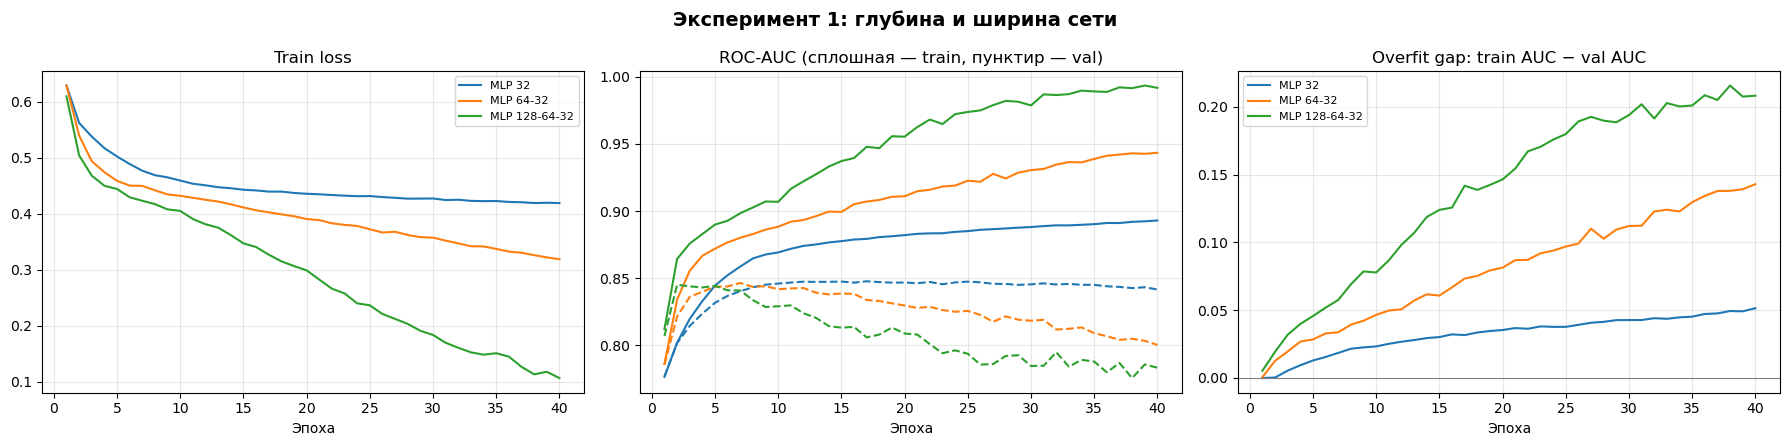

In [88]:
arch_configs = {
    'MLP 32':         dict(hidden_dims=(32,)),
    'MLP 64-32':      dict(hidden_dims=(64, 32)),
    'MLP 128-64-32':  dict(hidden_dims=(128, 64, 32)),
}

for name, cfg in arch_configs.items():
    run(name, cfg, epochs=40)

plot_histories(histories_of(arch_configs), 'Эксперимент 1: глубина и ширина сети')

**Вывод по эксперименту 1.** Лучший val ROC-AUC у всех трёх сетей практически одинаковый — 0.8478 / 0.8466 / 0.8452. Но ведут себя они совершенно по-разному, и видно это как раз на графиках:

| Сеть | Параметров | Пик val AUC на эпохе | train AUC (40-я) | val AUC (40-я) | Overfit gap |
|---|---|---|---|---|---|
| MLP 32 | 930 | 17 | 0.8930 | 0.8416 | 0.051 |
| MLP 64-32 | 3 874 | 7 | 0.9433 | 0.8005 | 0.143 |
| MLP 128-64-32 | 13 858 | 2 | 0.9916 | 0.7835 | 0.208 |

Чем больше сеть, тем раньше она достигает пика и тем сильнее валится после него. Самая большая заучивает train почти наизусть (train AUC 0.99) уже ко второй эпохе, а на валидации при этом теряет 0.06 AUC относительно маленькой сети.

Причина простая: 26 признаков и 6400 строк — это очень мало данных. Дополнительная ёмкость идёт не на выучивание закономерности, а на запоминание конкретных объектов. Дальше работаем с однослойной сетью `(32,)` на 930 параметров: она даёт то же качество и при этом переобучается медленнее всех, то есть с ней проще работать.

## Эксперимент 2: регуляризация

Берём архитектуру-победителя эксперимента 1 и добавляем регуляризацию: Dropout, BatchNorm, weight decay и их комбинацию. Смотрим на overfit gap (третий график) — именно его регуляризация должна уменьшать.

Архитектура-победитель эксперимента 1: (32,)
без регуляризации        | params:    930 | train AUC: 0.8930 | val AUC: 0.8416 | лучший val AUC: 0.8478
+ Dropout 0.3            | params:    930 | train AUC: 0.8837 | val AUC: 0.8453 | лучший val AUC: 0.8479
+ BatchNorm              | params:    994 | train AUC: 0.8971 | val AUC: 0.8367 | лучший val AUC: 0.8442
+ weight decay 1e-3      | params:    930 | train AUC: 0.8897 | val AUC: 0.8438 | лучший val AUC: 0.8485
+ BN + Drop + WD         | params:    994 | train AUC: 0.8779 | val AUC: 0.8469 | лучший val AUC: 0.8488


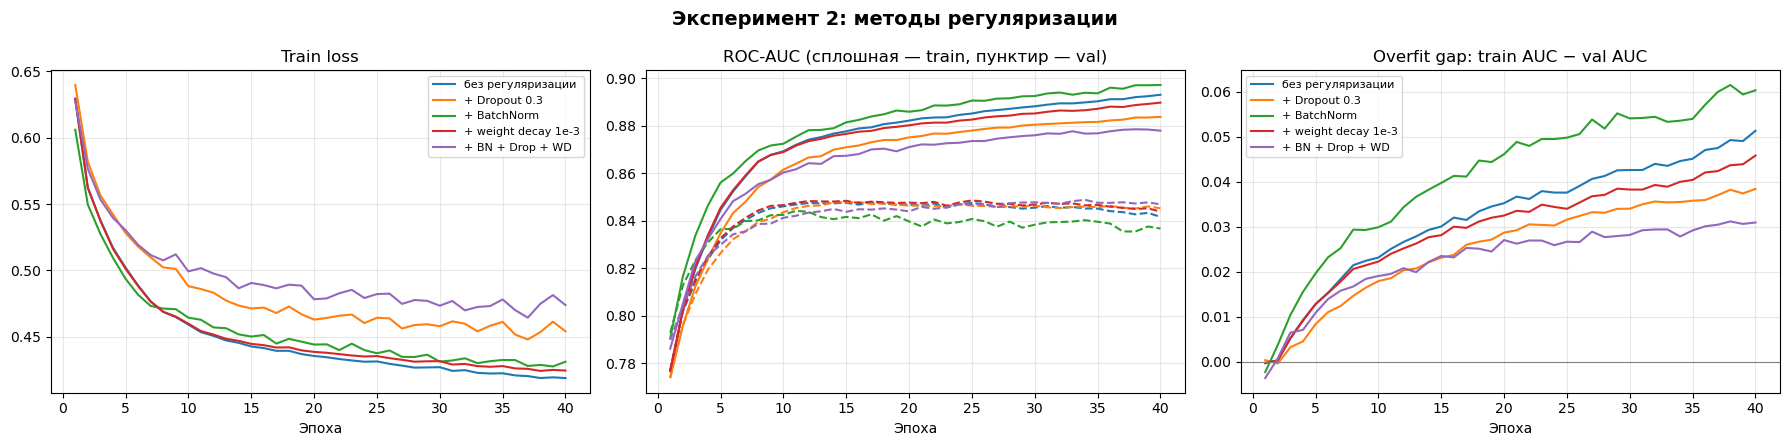

In [89]:
BASE_ARCH = RUNS[best_of(arch_configs)]['model_kwargs']['hidden_dims']
print(f'Архитектура-победитель эксперимента 1: {BASE_ARCH}')

reg_configs = {
    'без регуляризации':   dict(model_kwargs=dict(hidden_dims=BASE_ARCH)),
    '+ Dropout 0.3':       dict(model_kwargs=dict(hidden_dims=BASE_ARCH, dropout=0.3)),
    '+ BatchNorm':         dict(model_kwargs=dict(hidden_dims=BASE_ARCH, batchnorm=True)),
    '+ weight decay 1e-3': dict(model_kwargs=dict(hidden_dims=BASE_ARCH), weight_decay=1e-3),
    '+ BN + Drop + WD':    dict(model_kwargs=dict(hidden_dims=BASE_ARCH, dropout=0.3, batchnorm=True),
                                weight_decay=1e-3),
}

for name, cfg in reg_configs.items():
    run(name, epochs=40, **cfg)

plot_histories(histories_of(reg_configs), 'Эксперимент 2: методы регуляризации')

**Вывод по эксперименту 2.** Прирост лучшего val ROC-AUC от регуляризации маленький (0.8478 → 0.8488, то есть +0.001), и это ожидаемо: сеть `(32,)` и так почти не переобучалась. Главный эффект виден не в пике, а в устойчивости.

| Конфигурация | Лучший val AUC | val AUC на 40-й эпохе | Overfit gap |
|---|---|---|---|
| без регуляризации | 0.8478 | 0.8416 | 0.051 |
| + Dropout 0.3 | 0.8479 | 0.8453 | 0.038 |
| + BatchNorm | 0.8442 | 0.8367 | 0.060 |
| + weight decay 1e-3 | 0.8485 | 0.8438 | 0.046 |
| **+ BN + Dropout + WD** | **0.8488** | **0.8469** | **0.031** |

Комбинация трёх методов уменьшает overfit gap с 0.051 до 0.031 и держит val AUC на последней эпохе почти на уровне пика (0.8469 против 0.8488). Практически это означает, что результат перестаёт зависеть от того, на какой эпохе остановиться, — а это как раз то, ради чего регуляризация и нужна.

Отдельно любопытен BatchNorm сам по себе: он единственный ухудшил результат (0.8442, худший в таблице). На сети из одного слоя в 32 нейрона нормализовать особо нечего, а вот шум в батч-статистиках при `batch_size=64` он добавляет. В связке с Dropout этот шум перестаёт мешать и комбинация выходит в лидеры. Weight decay при этом почти догоняет комбинацию (0.8485) и стоит дешевле всего — одна строчка в оптимизаторе.

## Эксперимент 3: оптимизатор и learning rate

Архитектуру и регуляризацию берём от победителя эксперимента 2 и меняем только оптимизатор: Adam с двумя значениями lr, AdamW (decoupled weight decay), SGD с моментумом и Adam со снижением lr по расписанию (`StepLR`).

Регуляризация-победитель эксперимента 2: + BN + Drop + WD → {'hidden_dims': (32,), 'dropout': 0.3, 'batchnorm': True}
Adam lr=1e-3             | params:    994 | train AUC: 0.8786 | val AUC: 0.8468 | лучший val AUC: 0.8479
Adam lr=1e-2             | params:    994 | train AUC: 0.8877 | val AUC: 0.8409 | лучший val AUC: 0.8473
AdamW wd=1e-2            | params:    994 | train AUC: 0.8787 | val AUC: 0.8470 | лучший val AUC: 0.8481
SGD momentum             | params:    994 | train AUC: 0.8792 | val AUC: 0.8443 | лучший val AUC: 0.8468
Adam + StepLR            | params:    994 | train AUC: 0.8754 | val AUC: 0.8466 | лучший val AUC: 0.8469


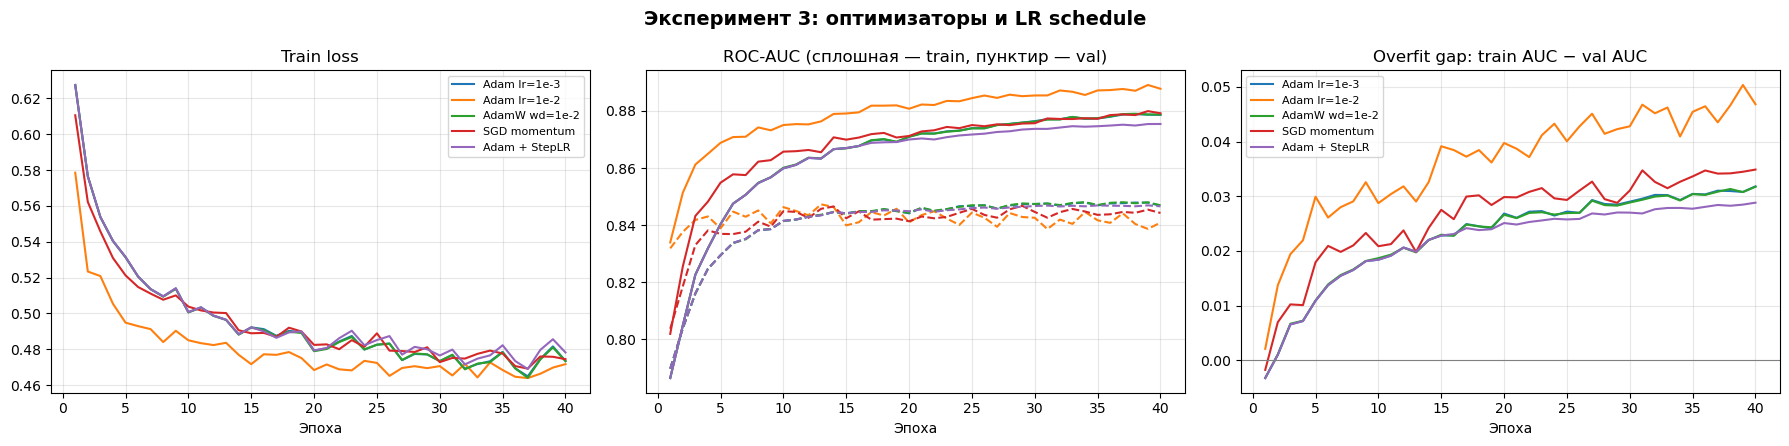

In [90]:
BEST_REG_NAME = best_of(reg_configs)
BEST_REG = RUNS[BEST_REG_NAME]['model_kwargs']
print(f'Регуляризация-победитель эксперимента 2: {BEST_REG_NAME} → {BEST_REG}')

step_lr = partial(optim.lr_scheduler.StepLR, step_size=15, gamma=0.5)

opt_configs = {
    'Adam lr=1e-3':  dict(optimizer_cls=optim.Adam, lr=1e-3),
    'Adam lr=1e-2':  dict(optimizer_cls=optim.Adam, lr=1e-2),
    'AdamW wd=1e-2': dict(optimizer_cls=optim.AdamW, lr=1e-3, weight_decay=1e-2),
    'SGD momentum':  dict(optimizer_cls=partial(optim.SGD, momentum=0.9), lr=1e-2),
    'Adam + StepLR': dict(optimizer_cls=optim.Adam, lr=1e-3, scheduler_cls=step_lr),
}

for name, cfg in opt_configs.items():
    run(name, BEST_REG, epochs=40, **cfg)

plot_histories(histories_of(opt_configs), 'Эксперимент 3: оптимизаторы и LR schedule')

**Вывод по эксперименту 3.** Все пять вариантов уложились в диапазон 0.8468–0.8481 — разброс 0.0013. Для сравнения, разброс ROC-AUC между фолдами кросс-валидации у классических моделей выше был около 0.01, то есть на порядок больше. Значит выбор оптимизатора на этой задаче ничего не решает, и любые выводы про «AdamW лучше Adam» здесь были бы подгонкой под шум.

Что всё-таки видно:
- **Adam с lr=1e-2** — единственный заметно выбивающийся вариант в худшую сторону (0.8473 в пике, 0.8409 на последней эпохе). Слишком большой шаг: сеть скачет вокруг минимума вместо того, чтобы в него садиться.
- **SGD с моментумом** сходится медленнее остальных и к 40-й эпохе ещё не догоняет Adam — ему бы пригодилось больше эпох или больший lr.
- **Adam + StepLR** даёт самый гладкий overfit gap (0.029, лучший в таблице): после снижения lr на 15-й и 30-й эпохе кривые перестают шуметь. Но на лучший val AUC это не влияет.

Вывод для проекта: узкое место здесь — объём данных и регуляризация, а не метод оптимизации. Оставляем Adam с lr=1e-3 по умолчанию.

## Итог экспериментов

Собираем все запуски в одну таблицу и берём конфигурацию с лучшим val ROC-AUC.

In [91]:
runs_table = pd.DataFrame([
    {
        'конфигурация': name,
        'лучший val AUC': max(r['history']['val_auc']),
        'лучшая эпоха': int(np.argmax(r['history']['val_auc'])) + 1,
        'val AUC на последней эпохе': r['history']['val_auc'][-1],
        'overfit gap': r['history']['train_auc'][-1] - r['history']['val_auc'][-1],
    }
    for name, r in RUNS.items()
]).sort_values('лучший val AUC', ascending=False).reset_index(drop=True)

runs_table

,конфигурация,лучший val AUC,лучшая эпоха,val AUC на последней эпохе,overfit gap
0,+ BN + Drop + WD,0.848795,34,0.846915,0.030958
1,+ weight decay 1e-3,0.848540,25,0.843842,0.045834
2,AdamW wd=1e-2,0.848054,34,0.846972,0.031740
3,Adam lr=1e-3,0.847916,38,0.846794,0.031812
4,+ Dropout 0.3,0.847890,16,0.845258,0.038428
5,MLP 32,0.847760,17,0.841642,0.051341
6,без регуляризации,0.847760,17,0.841642,0.051341
7,Adam lr=1e-2,0.847295,13,0.840900,0.046848
8,Adam + StepLR,0.846936,39,0.846597,0.028824
9,SGD momentum,0.846775,29,0.844276,0.034886


In [92]:
best_name = best_of(RUNS)
best_run = RUNS[best_name]
best_epoch = int(np.argmax(best_run['history']['val_auc'])) + 1

print(f'Лучшая конфигурация: {best_name}')
print(f'  архитектура:        {best_run["model_kwargs"]}')
print(f'  параметры обучения: {best_run["train_kwargs"]}')
print(f'  число эпох по валидации: {best_epoch}')

Лучшая конфигурация: + BN + Drop + WD
  архитектура:        {'hidden_dims': (32,), 'dropout': 0.3, 'batchnorm': True}
  параметры обучения: {'weight_decay': 0.001}
  число эпох по валидации: 34


## Финальная модель

Лучшую конфигурацию переобучаем с нуля на **всём** `X_train` (train + val = 8000 строк) — классические модели учились на том же объёме, иначе сравнение по `X_test` было бы нечестным. Число эпох фиксируем найденным на валидации: своей валидации на этом шаге уже нет, а подглядывать в тест нельзя.

In [93]:
preprocessor_mlp_full = ColumnTransformer([
    ('numeric', StandardScaler(), numeric_features_fe),
    ('categorical', OneHotEncoder(handle_unknown='ignore'), category_features_fe)
])
X_train_proc = preprocessor_mlp_full.fit_transform(X_train)
X_test_proc = preprocessor_mlp_full.transform(X_test)

full_fit_loader = make_loader(X_train_proc, y_train, batch_size=64, shuffle=True)
full_eval_loader = make_loader(X_train_proc, y_train, batch_size=512, shuffle=False)
test_loader = make_loader(X_test_proc, y_test, batch_size=512, shuffle=False)

counts_full = np.bincount(y_train)
class_weights_full = torch.tensor(len(y_train) / (2 * counts_full),
                                  dtype=torch.float32).to(device)

set_seed()
mlp_final = make_mlp(**best_run['model_kwargs'])

t0 = time.perf_counter()
train_model(mlp_final,
            fit_loader=full_fit_loader,
            train_eval=(full_eval_loader, y_train),
            name='MLP final', epochs=best_epoch,
            class_weights=class_weights_full, **best_run['train_kwargs'])
mlp_fit_time = time.perf_counter() - t0

print(f'Обучено на {len(y_train)} строках за {best_epoch} эпох, {mlp_fit_time:.1f} c')


MLP final                | params:    994 | train AUC: 0.8738
Обучено на 8000 строках за 34 эпох, 9.3 c


## Оценка на тестовой выборке

MLP ROC-AUC на тесте: 0.8723
MLP PR-AUC на тесте:  0.7215

              precision    recall  f1-score   support

           0      0.937     0.796     0.861      1592
           1      0.499     0.792     0.612       408

    accuracy                          0.795      2000
   macro avg      0.718     0.794     0.737      2000
weighted avg      0.848     0.795     0.810      2000



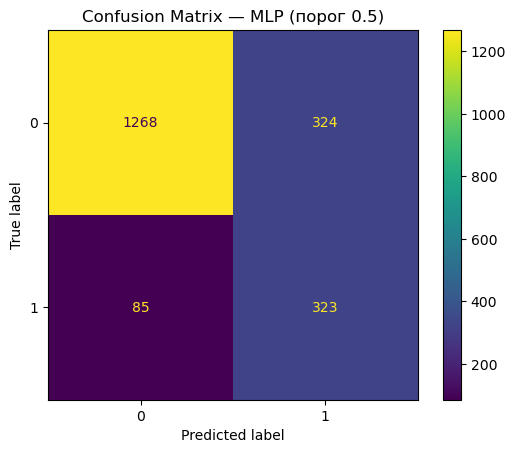

In [94]:
test_probs = predict_proba(mlp_final, test_loader)
mlp_test_auc = roc_auc_score(y_test, test_probs)
mlp_test_pr_auc = average_precision_score(y_test, test_probs)

print(f'MLP ROC-AUC на тесте: {mlp_test_auc:.4f}')
print(f'MLP PR-AUC на тесте:  {mlp_test_pr_auc:.4f}\n')

mlp_test_preds = (test_probs >= 0.5).astype(int)
print(classification_report(y_test, mlp_test_preds, digits=3))

ConfusionMatrixDisplay.from_predictions(y_test, mlp_test_preds)
plt.title('Confusion Matrix — MLP (порог 0.5)')
plt.show()


## Сравнение MLP с классикой на одном `X_test`

Выше классические модели оценивались по 5-fold CV на train, а MLP — на hold-out. Это несравнимые числа. Здесь дообучаем три tuned-модели на полном `X_train` и считаем метрики на том же `X_test`, что и у MLP.

In [95]:
classic_tuned = {
    'LogReg (tuned)': logreg_tuned_model,
    'Random Forest (tuned)': rf_tuned_model,
    'LightGBM (tuned)': lgb_tuned_model,
}

rows = []
for name, model in classic_tuned.items():
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    fit_time = time.perf_counter() - t0
    probs = model.predict_proba(X_test)[:, 1]
    rows.append({
        'model': name,
        'ROC-AUC (test)': roc_auc_score(y_test, probs),
        'PR-AUC (test)': average_precision_score(y_test, probs),
        'fit time, s': fit_time,
    })

rows.append({
    'model': 'MLP (tuned)',
    'ROC-AUC (test)': mlp_test_auc,
    'PR-AUC (test)': mlp_test_pr_auc,
    'fit time, s': mlp_fit_time,
})

test_comparison = (pd.DataFrame(rows)
                   .sort_values('ROC-AUC (test)', ascending=False)
                   .reset_index(drop=True))
test_comparison

,model,ROC-AUC (test),PR-AUC (test),"fit time, s"
0,LightGBM (tuned),0.879309,0.730696,0.325295
1,MLP (tuned),0.872323,0.721534,9.345016
2,Random Forest (tuned),0.868694,0.711185,0.722640
3,LogReg (tuned),0.800370,0.559529,0.078366


## Выводы по MLP

**Итоговая конфигурация:** один скрытый слой на 32 нейрона, `BatchNorm + ReLU + Dropout(0.3)`, weight decay 1e-3, Adam lr=1e-3, 34 эпохи. Всего 994 параметра.

**Качество на тесте:** ROC-AUC 0.8723, PR-AUC 0.7215.

**Сравнение с классическими моделями на одном `X_test`:**

| Модель | ROC-AUC | PR-AUC | Время обучения |
|---|---|---|---|
| LightGBM (tuned) | 0.8793 | 0.7307 | 0.33 с |
| MLP (tuned) | 0.8723 | 0.7215 | 9.35 с |
| Random Forest (tuned) | 0.8687 | 0.7112 | 0.72 с |
| LogReg (tuned) | 0.8004 | 0.5595 | 0.08 с |

**Качество MLP.** Качество определялось не размером сети, а регуляризацией: самая большая архитектура (13 858 параметров) оказалась худшей, а лучший результат дала самая маленькая (930–994 параметра) с полным набором регуляризаторов. На табличных данных такого объёма, увеличение сети нейронной сети почти всегда ведет к переобучению, а не к повышению качества.


# 6. Stacking

Собираем ансамбль из трёх настроенных моделей: LogReg, Random Forest и LightGBM. Мета-моделью берём логистическую регрессию — она получает на вход вероятности базовых моделей и учится их взвешивать.

`StackingClassifier` с `cv=cv` сам обучает базовые модели на фолдах и формирует out-of-fold предсказания для мета-модели, поэтому утечки из обучающей выборки в мета-признаки не возникает.

Смысл ансамбля здесь в том, что модели ошибаются по-разному: LogReg ловит линейную часть сигнала, деревья — пороги и взаимодействия. Если их ошибки не полностью коррелированы, взвешенная комбинация должна быть точнее любой одиночной модели.

In [96]:
from sklearn.ensemble import StackingClassifier
from sklearn.inspection import permutation_importance

stacking_model = StackingClassifier(
    estimators=[
        ('logreg', logreg_tuned_model),
        ('rf', rf_tuned_model),
        ('lgbm', lgb_tuned_model),
    ],
    final_estimator=LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    cv=cv,
    n_jobs=None,
)

t0 = time.perf_counter()
stacking_model.fit(X_train, y_train)
stacking_fit_time = time.perf_counter() - t0

stacking_probs = stacking_model.predict_proba(X_test)[:, 1]
print(f'Stacking ROC-AUC на тесте: {roc_auc_score(y_test, stacking_probs):.4f}')
print(f'Время обучения: {stacking_fit_time:.1f} c')

Stacking ROC-AUC на тесте: 0.8777
Время обучения: 7.1 c


In [97]:
meta_weights = pd.Series(
    stacking_model.final_estimator_.coef_[0],
    index=[name for name, _ in stacking_model.estimators]
).sort_values(ascending=False)

print('Коэффициенты мета-модели:')
print(meta_weights.round(3))


Коэффициенты мета-модели:
lgbm      4.578
rf        2.368
logreg    0.143
dtype: float64


# 7. Сравнение всех моделей

Все модели дообучаются на полном `X_train` и оцениваются на одном и том же `X_test`. Пороговые метрики (accuracy, precision, recall, F1) считаются при стандартном пороге 0.5 — так они сопоставимы между моделями.

SVM пересобираем с `probability=True`: исходная версия обучалась без калибровки вероятностей, а для PR-AUC и сравнения по порогу они нужны.

In [98]:
svm_prob_model = Pipeline([
    ('preprocessor', preprocessor_svm_base),
    ('model', SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE))
])

def eval_on_test(name, probs, fit_time, threshold=0.5):
    preds = (probs >= threshold).astype(int)
    return {
        'Модель': name,
        'ROC-AUC': roc_auc_score(y_test, probs),
        'PR-AUC': average_precision_score(y_test, probs),
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, zero_division=0),
        'Recall': recall_score(y_test, preds),
        'F1': f1_score(y_test, preds, zero_division=0),
        'Время обучения, с': fit_time,
    }

models_for_table = {
    'LogReg (base)': logreg_base_model,
    'LogReg (tuned)': logreg_tuned_model,
    'KNN (base)': knn_base_model,
    'SVM RBF': svm_prob_model,
    'Random Forest (base)': rf_model_base,
    'Random Forest (tuned)': rf_tuned_model,
    'LightGBM (base)': lgb_base_model,
    'LightGBM (tuned)': lgb_tuned_model,
    'Stacking': stacking_model,
}

results, test_probs_all = [], {}

for name, model in models_for_table.items():
    if name == 'Stacking':
        probs, fit_time = stacking_probs, stacking_fit_time
    else:
        t0 = time.perf_counter()
        model.fit(X_train, y_train)
        fit_time = time.perf_counter() - t0
        probs = model.predict_proba(X_test)[:, 1]
    test_probs_all[name] = probs
    results.append(eval_on_test(name, probs, fit_time))

test_probs_all['MLP (tuned)'] = test_probs
results.append(eval_on_test('MLP (tuned)', test_probs, mlp_fit_time))

final_table = (pd.DataFrame(results)
               .sort_values('ROC-AUC', ascending=False)
               .reset_index(drop=True))
final_table.round(4)


,Модель,ROC-AUC,PR-AUC,Accuracy,Precision,Recall,F1,"Время обучения, с"
0,LightGBM (tuned),0.8793,0.7307,0.8685,0.7843,0.4902,0.6033,0.3685
1,Stacking,0.8777,0.7278,0.8690,0.7570,0.5270,0.6214,7.0808
2,MLP (tuned),0.8723,0.7215,0.7955,0.4992,0.7917,0.6123,9.3450
3,Random Forest (tuned),0.8687,0.7112,0.8730,0.8438,0.4632,0.5981,0.7617
4,Random Forest (base),0.8615,0.6909,0.8690,0.8017,0.4755,0.5969,1.0393
5,LightGBM (base),0.8512,0.6763,0.8515,0.6934,0.4877,0.5727,0.2707
6,SVM RBF,0.8372,0.6883,0.8660,0.7991,0.4583,0.5826,8.3736
7,LogReg (tuned),0.8004,0.5595,0.7250,0.4035,0.7279,0.5192,0.0797
8,LogReg (base),0.7784,0.4865,0.8130,0.6232,0.2108,0.3150,0.0223
9,KNN (base),0.7587,0.4640,0.8250,0.6343,0.3358,0.4391,0.0111


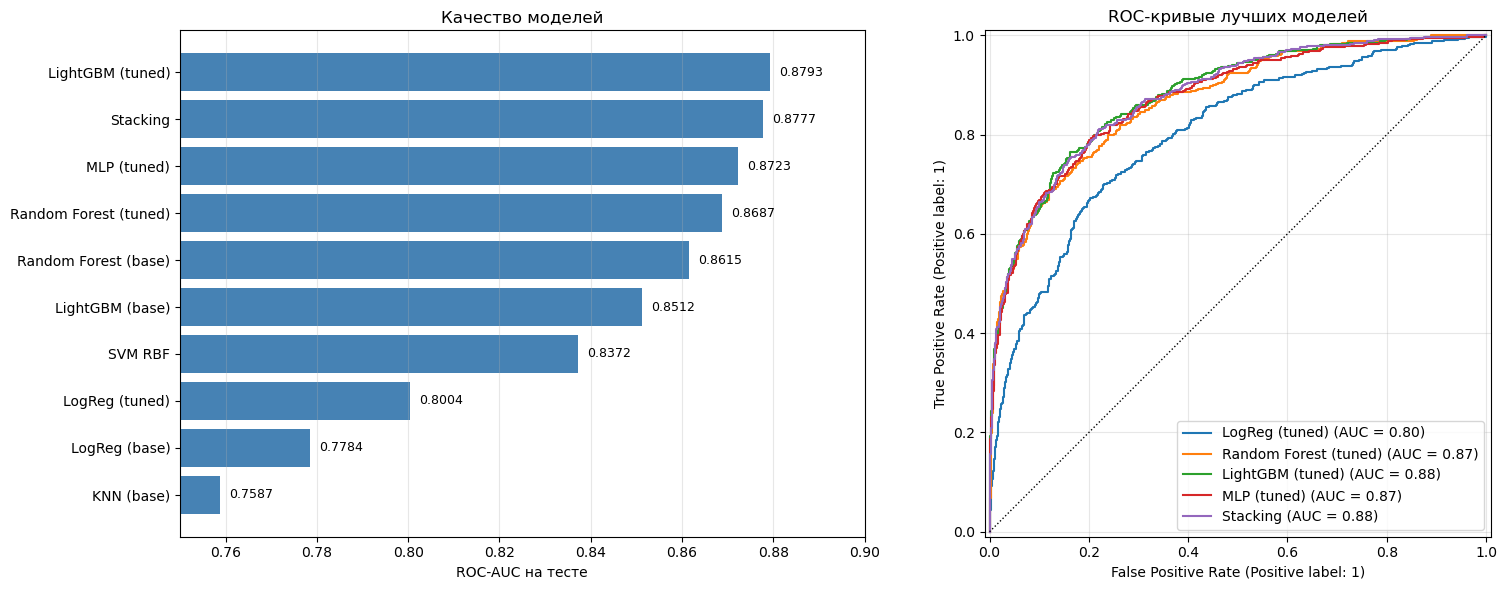

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

order = final_table['Модель']
axes[0].barh(order, final_table['ROC-AUC'], color='steelblue')
axes[0].set_xlim(0.75, 0.90)
axes[0].invert_yaxis()
axes[0].set_xlabel('ROC-AUC на тесте')
axes[0].set_title('Качество моделей')
axes[0].grid(True, axis='x', alpha=0.3)
for y, v in enumerate(final_table['ROC-AUC']):
    axes[0].text(v + 0.002, y, f'{v:.4f}', va='center', fontsize=9)

for name in ['LogReg (tuned)', 'Random Forest (tuned)', 'LightGBM (tuned)', 'MLP (tuned)', 'Stacking']:
    RocCurveDisplay.from_predictions(y_test, test_probs_all[name], name=name, ax=axes[1])
axes[1].plot([0, 1], [0, 1], 'k:', lw=1)
axes[1].set_title('ROC-кривые лучших моделей')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 8. Feature importance

Смотрим, на что опирается лучшая модель. Два взгляда:

* **Gain importance** — сколько суммарно каждый признак дал прироста качества сплитов внутри LightGBM. Быстро, но смещено в сторону признаков с большим числом уникальных значений.
* **Permutation importance** — насколько падает ROC-AUC на тесте, если случайно перемешать один признак. Считается на исходных колонках (до one-hot), медленнее, но честнее и интерпретируется напрямую.

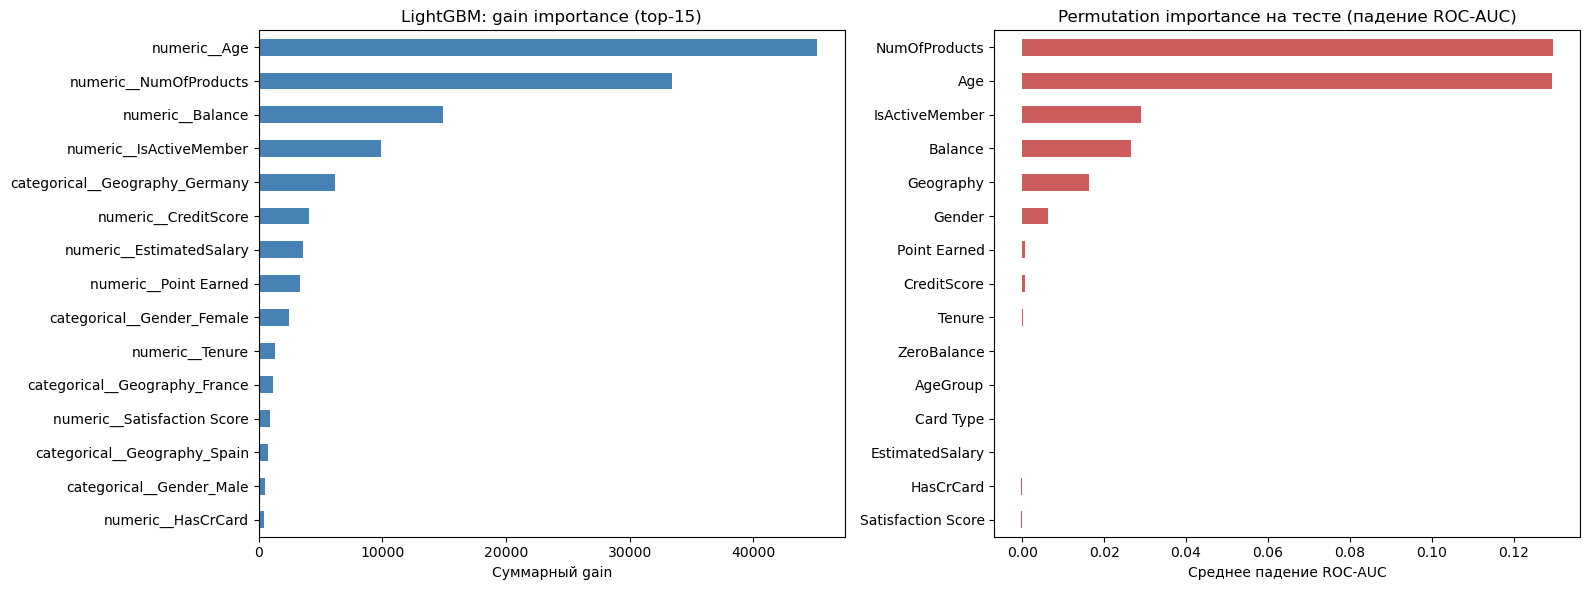

Permutation importance (top-10):
NumOfProducts     0.1297
Age               0.1293
IsActiveMember    0.0290
Balance           0.0264
Geography         0.0164
Gender            0.0063
Point Earned      0.0008
CreditScore       0.0007
Tenure            0.0003
AgeGroup          0.0000
dtype: float64


In [100]:
booster = lgb_tuned_model.named_steps['model'].booster_
feat_names = lgb_tuned_model.named_steps['preprocessor'].get_feature_names_out()
gain = pd.Series(booster.feature_importance(importance_type='gain'),
                 index=feat_names).sort_values(ascending=False).head(15)

perm = permutation_importance(
    lgb_tuned_model, X_test, y_test,
    n_repeats=10, random_state=RANDOM_STATE, scoring='roc_auc', n_jobs=-1
)
perm_s = (pd.Series(perm.importances_mean, index=X_test.columns)
          .sort_values(ascending=False).head(15))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

gain.sort_values().plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('LightGBM: gain importance (top-15)')
axes[0].set_xlabel('Суммарный gain')

perm_s.sort_values().plot.barh(ax=axes[1], color='indianred')
axes[1].set_title('Permutation importance на тесте (падение ROC-AUC)')
axes[1].set_xlabel('Среднее падение ROC-AUC')

plt.tight_layout()
plt.show()

print('Permutation importance (top-10):')
print(perm_s.head(10).round(4))

# 9. Бизнес-метрики: ROI кампании удержания

Метрики вроде ROC-AUC говорят, насколько хорошо модель ранжирует клиентов, но не отвечают на вопрос, сколько денег она приносит. Переведём качество моделей в рубли и выберем ту, которая зарабатывает больше всех.

**Допущения** (это именно допущения — реальные цифры берутся из финансовой отчётности банка):

| Параметр | Значение | Смысл |
|---|---|---|
| `LTV` | 20 000 ₽ | Прибыль, которую приносит удержанный клиент |
| `RETENTION_COST` | 3 000 ₽ | Стоимость удерживающей кампании на одного клиента |
| `SUCCESS_RATE` | 35% | Доля клиентов, которых кампания действительно удерживает |

**Прибыль кампании:**

```
Прибыль = TP × SUCCESS_RATE × LTV − (TP + FP) × RETENTION_COST
```

Тратимся на всех, кого модель пометила как уходящих (`TP + FP`), а возвращаем деньги только с той доли действительно уходящих (`TP`), которую удалось удержать.

Все модели сравниваем при **одном и том же пороге 0.5** — том же, при котором считались accuracy, precision, recall и F1 в разделе 7. Подбор порога не делаем: иначе у каждой модели он был бы свой, и таблица сравнивала бы не модели, а качество подгонки порога.

Две особенности формулы, которые важно понимать при чтении таблицы:

* **`FN` ничего не стоит.** Упущенный уходящий клиент не штрафуется — прибыль считается относительно сценария «ничего не делаем». Модель может пропустить почти всех уходящих и всё равно остаться в плюсе, просто заработает мало.
* **`TN` не приносит и не стоит ничего.** Клиенты, которых модель верно не тронула, в расчёт вообще не входят. Именно поэтому accuracy здесь бесполезна как ориентир: она почти целиком определяется этим большим и экономически нейтральным квадратом.


In [101]:
LTV = 20_000
RETENTION_COST = 3_000
SUCCESS_RATE = 0.35
THRESHOLD = 0.5


def campaign_profit(y_true, probs, threshold=THRESHOLD,
                    ltv=LTV, cost=RETENTION_COST, success=SUCCESS_RATE):
    """Прибыль кампании при заданном пороге: возвращаем (прибыль, TP, FP)."""
    preds = (probs >= threshold).astype(int)
    y_true = np.asarray(y_true)
    tp = int(((preds == 1) & (y_true == 1)).sum())
    fp = int(((preds == 1) & (y_true == 0)).sum())
    return tp * success * ltv - (tp + fp) * cost, tp, fp


In [102]:
n_test = len(y_test)
n_churn = int(np.asarray(y_test).sum())

profit_nobody = 0
profit_everybody = campaign_profit(y_test, np.ones(n_test))[0]

auc_by_model = final_table.set_index('Модель')['ROC-AUC'].to_dict()

rows = []
for name, probs in test_probs_all.items():
    profit, tp, fp = campaign_profit(y_test, probs)
    spend = (tp + fp) * RETENTION_COST
    rows.append({
        'Модель': name,
        'ROC-AUC': auc_by_model[name],
        'Звоним': tp + fp,
        'Из них уходящих': tp,
        'Прибыль, ₽': profit,
        'ROI, %': 100 * profit / spend if spend else np.nan,
    })

business = pd.DataFrame(rows).sort_values('Прибыль, ₽', ascending=False).reset_index(drop=True)

print(f'Тестовая выборка: {n_test} клиентов, из них уходят {n_churn} ({100 * n_churn / n_test:.1f}%)')
print(f'Порог для всех моделей: {THRESHOLD}')
print()
print(f'Не делать ничего:  прибыль {profit_nobody:,.0f} ₽')
print(f'Обзванивать всех:  прибыль {profit_everybody:,.0f} ₽')
print()
business.round(4)


Тестовая выборка: 2000 клиентов, из них уходят 408 (20.4%)
Порог для всех моделей: 0.5

Не делать ничего:  прибыль 0 ₽
Обзванивать всех:  прибыль -3,144,000 ₽



,Модель,ROC-AUC,Звоним,Из них уходящих,"Прибыль, ₽","ROI, %"
0,Stacking,0.8777,284,215,653000.0,76.6432
1,Random Forest (tuned),0.8687,224,189,651000.0,96.8750
2,LightGBM (tuned),0.8793,255,200,635000.0,83.0065
3,Random Forest (base),0.8615,242,194,632000.0,87.0523
4,SVM RBF,0.8372,234,187,607000.0,86.4672
5,LightGBM (base),0.8512,287,199,532000.0,61.7886
6,MLP (tuned),0.8723,647,323,320000.0,16.4863
7,KNN (base),0.7587,216,137,311000.0,47.9938
8,LogReg (base),0.7784,138,86,188000.0,45.4106
9,LogReg (tuned),0.8004,736,297,-129000.0,-5.8424


# 10. Итоговые выводы

Проект прошёл полный цикл: EDA → feature engineering → пять классических моделей → подбор гиперпараметров → нейронная сеть → ансамбль → экономическая оценка.
## Итоговое качество

Все модели обучены на `X_train` (8000 строк) и оценены на отложенном `X_test` (2000 строк) при одном пороге 0.5.

| Модель | ROC-AUC | PR-AUC | F1 @0.5 | Время обучения |
|---|---|---|---|---|
| **LightGBM (tuned)** | **0.8793** | **0.7307** | 0.6033 | 0.37 с |
| Stacking | 0.8777 | 0.7278 | **0.6214** | 7.08 с |
| MLP (tuned) | 0.8723 | 0.7215 | 0.6123 | 9.35 с |
| Random Forest (tuned) | 0.8687 | 0.7112 | 0.5981 | 0.76 с |
| Random Forest (base) | 0.8615 | 0.6909 | 0.5969 | 1.04 с |
| LightGBM (base) | 0.8512 | 0.6763 | 0.5727 | 0.27 с |
| SVM RBF | 0.8372 | 0.6883 | 0.5826 | 8.37 с |
| LogReg (tuned) | 0.8004 | 0.5595 | 0.5192 | 0.08 с |
| LogReg (base) | 0.7784 | 0.4865 | 0.3150 | 0.02 с |
| KNN (base) | 0.7587 | 0.4640 | 0.4391 | 0.01 с |

## Почему выиграл градиентный бустинг

Отток определяется **резкими порогами и взаимодействиями признаков**, а не плавными линейными зависимостями:
- возраст: 7.5% оттока в группе 18–30, 56.2% в группе 50–60, и снова падение до 24.8% после 60 — немонотонная зависимость, которую линейная модель не может выразить в принципе;
- число продуктов: 27.7% при одном продукте, 7.6% при двух, дальше резкий скачок вверх — ступенька, а не наклон;
- география: Германия выделяется вдвое (32% против 16%), но только в сочетании с другими признаками.

Дерево режет такой порог одним сплитом. Логистической регрессии для того же нужен явный биннинг — именно поэтому FE (`AgeGroup`, `ZeroBalance`) поднял её с 0.7628 до 0.7812, а деревьям не дал ничего (RF 0.8509 → 0.8435, LightGBM 0.8400 → 0.8403). Это прямое подтверждение: деревья находят те же пороги сами, и ручной FE для них — избыточная работа, добавляющая размерность.

## Почему стекинг не помог

Ансамбль дал 0.8777 против 0.8793 у одиночного LightGBM, то есть **проиграл 0.0016**. Это не ошибка сборки, а следствие состава.

Коэффициенты мета-модели: `lgbm 4.58`, `rf 2.37`, `logreg 0.14`. Логистическая регрессия получила почти нулевой вес — мета-модель сочла её бесполезной. Остались две модели одного семейства, которые режут одни и те же пороги по одним и тем же признакам, то есть **ошибаются на одних и тех же объектах**. Стекинг выигрывает, когда ошибки базовых моделей некоррелированы; здесь этого условия нет.

При этом по F1 при пороге 0.5 стекинг всё же лучший (0.6214 против 0.6033): усреднение двух деревянных моделей сдвигает вероятности к более удачной для этого порога калибровке. То есть польза есть, но не в ранжировании, а в откалиброванности.

Чтобы стекинг реально сработал, в него нужно добавить модель с другой природой ошибок — MLP или SVM, которые строят гладкие границы вместо ступенек.

## MLP на табличных данных

Сеть заняла третье место (0.8723), обойдя Random Forest и отстав от LightGBM на 0.007. Вывод не «нейросети хуже», а более узкий: **на 8000 строк с 26 признаками сеть конкурентоспособна, но не даёт преимущества**, а стоит в 25 раз дороже по времени обучения и заметно сложнее в настройке.

Три эксперимента раздела 5 показали, где именно у неё узкое место. Увеличение сети с 930 до 13 858 параметров **ухудшило** результат (overfit gap вырос с 0.051 до 0.208), регуляризация дала +0.001 к пику, но сократила gap до 0.031, а выбор оптимизатора не повлиял вовсе (разброс 0.0013 при разбросе между фолдами CV около 0.01). Ограничение — объём данных, а не архитектура.

## Что на самом деле предсказывает отток

Permutation importance на тесте (падение ROC-AUC при перемешивании признака):

| Признак | Вклад |
|---|---|
| NumOfProducts | 0.1297 |
| Age | 0.1293 |
| IsActiveMember | 0.0290 |
| Balance | 0.0264 |
| Geography | 0.0164 |
| Gender | 0.0063 |
| Point Earned | 0.0008 |
| CreditScore | 0.0007 |
| Tenure | 0.0003 |
| AgeGroup | 0.0000 |

Два признака дают почти весь сигнал (0.130 и 0.129), все остальные вместе — меньше 0.08. `Point Earned`, `CreditScore`, `Tenure`, `Card Type` и `Satisfaction Score` практически не работают: их вклад на уровне 0.001 и ниже, что подтверждает вывод EDA об их одинаковом распределении по классам. Любопытно, что `Satisfaction Score` — субъективная оценка удовлетворённости — не предсказывает уход вообще, а объективное число продуктов предсказывает лучше всего.

Отдельно стоит отметить, что мы **не использовали** `Complain`, хотя он даёт корреляцию 0.996 с таргетом. С ним любая модель показала бы ROC-AUC около 0.999 — и была бы бесполезна в проде, потому что жалоба фиксируется в момент ухода, а не до него.

## Бизнес-выводы

Экономика кампании удержания при допущениях LTV 20 000 ₽, стоимость контакта 3 000 ₽, успешность удержания 35%. Порог у всех моделей одинаковый — 0.5:

| Стратегия | Звоним | Из них уходящих | Прибыль | ROI |
|---|---|---|---|---|
| Не делать ничего | 0 | 0 | 0 ₽ | — |
| **Обзванивать всех** | 2000 | 408 | **−3 144 000 ₽** | −52.4% |
| **Stacking** | 284 | 215 | **653 000 ₽** | 76.6% |
| Random Forest (tuned) | 224 | 189 | 651 000 ₽ | **96.9%** |
| LightGBM (tuned) | 255 | 200 | 635 000 ₽ | 83.0% |
| Random Forest (base) | 242 | 194 | 632 000 ₽ | 87.1% |
| SVM RBF | 234 | 187 | 607 000 ₽ | 86.5% |
| LightGBM (base) | 287 | 199 | 532 000 ₽ | 61.8% |
| MLP (tuned) | 647 | 323 | 320 000 ₽ | 16.5% |
| KNN (base) | 216 | 137 | 311 000 ₽ | 48.0% |
| LogReg (base) | 138 | 86 | 188 000 ₽ | 45.4% |
| LogReg (tuned) | 736 | 297 | −129 000 ₽ | −5.8% |

**Кампания без модели убыточна.** Обзванивать всех — минус 3.1 млн, потому что 80% контактов уходят на клиентов, которые и так остались бы. Модель превращает этот убыток в 653 тысячи прибыли на тех же 2000 клиентов.

**Лучшая по метрике и лучшая по деньгам — разные модели.** LightGBM выигрывает по ROC-AUC (0.8793), но по прибыли только третья: стекинг зарабатывает на 18 тысяч больше, а Random Forest даёт почти столько же денег при вдвое меньшем ROI-риске — 224 звонка против 255 и ROI 96.9%. Ранжирование и прибыль при фиксированном пороге — не одно и то же.

**Провал MLP и LogReg (tuned) — артефакт калибровки, а не качества.** Обе обучены с весами классов (`class_weight='balanced'` и веса в `CrossEntropyLoss`), поэтому систематически завышают вероятность класса 1. При пороге 0.5 они помечают 647 и 736 клиентов вместо ~250 у остальных: у LogReg 439 звонков из 736 уходят впустую, и кампания уходит в минус. По ранжированию LogReg (tuned) лучше LogReg (base) — 0.8004 против 0.7784, — а по деньгам хуже. Прежде чем считать деньги по порогу, модели с весами классов нужно калибровать.
